# 1. Load Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
customers = pd.read_csv('D:/marketing-driven-data-unlock/data/raw/olist_customers_dataset.csv')
geolocation = pd.read_csv("D:/marketing-driven-data-unlock/data/raw/olist_geolocation_dataset.csv")
items = pd.read_csv("D:/marketing-driven-data-unlock/data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("D:/marketing-driven-data-unlock/data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("D:/marketing-driven-data-unlock/data/raw/olist_order_reviews_dataset.csv")
orders = pd.read_csv("D:/marketing-driven-data-unlock/data/raw/olist_orders_dataset.csv")
products = pd.read_csv("D:/marketing-driven-data-unlock/data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("D:/marketing-driven-data-unlock/data/raw/olist_sellers_dataset.csv")

# 2. Data Description

## customers.csv

| Variable | Data Type | Description |
|---|---|---|
| `customer_id` | string | Primary key; identifier for each customer |
| `customer_unique_id` | string | Unique identifier of a customer |
| `customer_zip_code_prefix` | integer | Customer postal code |
| `customer_city` | string | Customer city |
| `customer_state` | string | Customer gender; nullable |


## geography.csv

| Variable | Data Type | Description |
|---|---|---|
| `geolocation_zip_code_prefix` | integer | Primary key; postal code |
| `geolocation_lat` | string | Latitude |
| `geolocation_lng` | string | Longtitude |
| `geolocation_city` | string | City name |
| `geolocation_state` | string | State |


## order_items.csv

| Variable | Data Type | Description |
|---|---|---|
| `order_id` | string | Foreign key linking to orders |
| `order_item_id` | integer | Identify number of items included in the same order |
| `product_id` | string | Foreign key linking to products |
| `seller_id` | string | Foreign key linking to sellers |
| `shipping_limit_date` | datetime | Deadline for the seller to hand over the order to the logistics partner. |
| `price` | float | Item price |
| `freight_value` | float | Iteam freight value (split across items if an order contains multiple items) |


## order_payments.csv

| Variable | Data Type | Description |
|---|---|---|
| `order_id` | string | Foreign key linking to orders |
| `payment_sequential` | integer | Sequence number of payments for an order when multiple payment methods are used |
| `payment_type` | string | Method of payment |
| `payment_installments` | integer | Number of payment installments |
| `payment_value` | float | Total payment value |


## order_reviews.csv

| Variable | Data Type | Description |
|---|---|---|
| `review_id` | string | Primary key; unique identifier for each review |
| `order_id` | string | Foreign key linking to orders |
| `review_score` | float | Customer's satisfying score range 1-5 |
| `review_creation_date` | string | Date when the survey send to customers |
| `review_answer_timestamp` | string | Date when customers answer survey |


## orders.csv

| Variable | Data Type | Description |
|---|---|---|
| `order_id` | string | Primary key; unique identifier for each order |
| `customer_id` | string | Foreign key linking to customers |
| `order_status` | string | Order status |
| `order_purchase_timestamp` | string | Shows the purchase timestamp |
| `order_approved_at` | string | Shows the payment approval timestamp |
| `order_delivered_carrier_date` | string | Timestamp which order handled to  logistic partner |
| `order_delivered_customer_date` | string | Timestamp that actual order delivery to the customer |
| `order_estimated_delivery_date` | string | Expected delivery date communicated to the customer at the time of purchase |


## products.csv

| Variable | Data Type | Description |
|---|---|---|
| `product_id` | string | Primary key; unique identifier for each product |
| `product_category_name` | string | Root category of product |
| `product_name_lenght` | float | Number of characters extracted from the product name |
| `product_description_lenght` | float | Number of characters extracted from the product description|
| `product_photos_qty` | float | Number of product published photos |
| `product_weight_g` | float | Product weight measured in grams |
| `product_length_cm` | float | Product length measured in centimeters |
| `product_width_cm` | float | Product weight measured in centimeters |


## sellers.csv

| Variable | Data Type | Description |
|---|---|---|
| `seller_id` | string | Primary key; unique identifier for each seller |
| `seller_zip_code_prefix` | integer | Seller postal code |
| `seller_city` | string | Seller city name |
| `seller_state` | string | Seller city state |




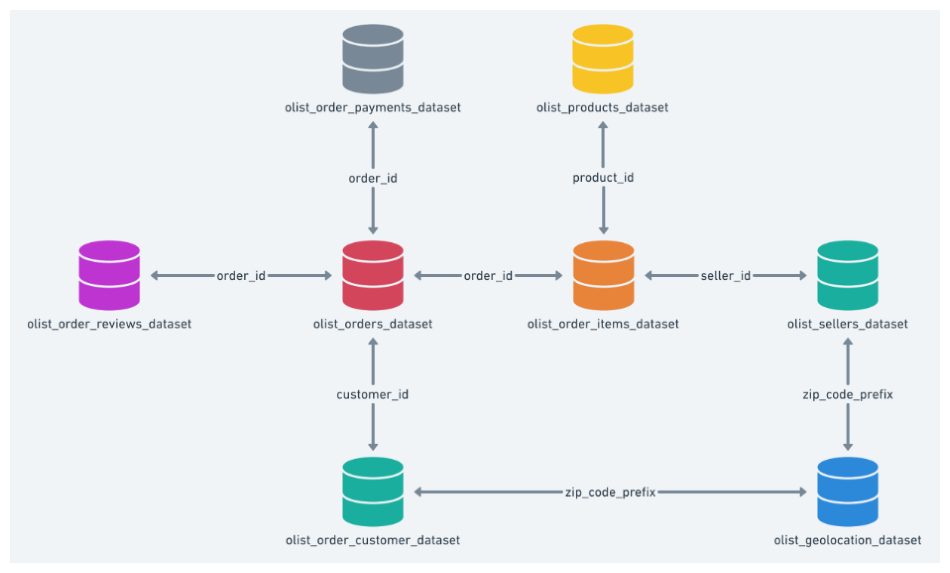

In [ ]:
import matplotlib.image as mpimg

# Đọc ảnh
img = mpimg.imread("diagram.png")

# Hiển thị ảnh
plt.figure(figsize=(12, 12))

plt.imshow(img)
plt.axis('off')  # Tắt trục
plt.show()

# 3. Data Overview

## 3.1 Structure check

In [ ]:
data = {
    "customers": customers,
    "geolocation": geolocation,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers
}

In [ ]:
shape_rows = []

for table_name, df in data.items():
    shape_rows.append({
        "table_name": table_name,
        "n_rows": df.shape[0],
        "n_columns": df.shape[1],
        "total_cells": df.shape[0] * df.shape[1]
    })

shape_df = pd.DataFrame(shape_rows)
shape_df

,table_name,n_rows,n_columns,total_cells
0,customers,99441,5,497205
1,geolocation,1000163,5,5000815
2,items,112650,7,788550
3,payments,103886,5,519430
4,reviews,99224,5,496120
5,orders,99441,8,795528
6,products,32951,9,296559
7,sellers,3095,4,12380


## 3.2 Missing values check

In [ ]:
missing_rows = []

for table_name, df in data.items():
    for col in df.columns:
        missing_count = df[col].isna().sum()
        missing_pct = df[col].isna().mean() * 100
        
        if missing_count > 0:   # chỉ giữ những cột có missing
            missing_rows.append({
                "table_name": table_name,
                "column_name": col,
                "missing_count": missing_count,
                "missing_pct": round(missing_pct, 2)
            })

missing_only_df = pd.DataFrame(missing_rows)

missing_only_df = missing_only_df.sort_values(
    by=["missing_pct", "missing_count"],
    ascending=False
)

missing_only_df

,table_name,column_name,missing_count,missing_pct
2,orders,order_delivered_customer_date,2965,2.98
3,products,product_category_name,623,1.89
4,products,product_name_lenght,610,1.85
5,products,product_description_lenght,610,1.85
6,products,product_photos_qty,610,1.85
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16
7,products,product_weight_g,2,0.01
8,products,product_length_cm,2,0.01
9,products,product_height_cm,2,0.01


- Analysis reveals a significant scale disparity between datasets, with the Geolocation table being the largest. Regarding data quality, columns related to actual delivery timestamps show the highest missing value percentages, reflecting orders that are either in-transit or canceled mid-process.

## 3.3 Duplicate check

In [ ]:
primary_keys = {
    "customers": "customer_id",
    "orders": "order_id",
    "products": "product_id",
    "sellers": "seller_id",
    "reviews": "review_id",
}

composite_keys = [
    {
        "table_name": "items",
        "key_cols": ["order_id", "order_item_id"]
    },
    {
        "table_name": "payments",
        "key_cols": ["order_id", "payment_sequential"]
    }
]

pk_results = []

def check_and_clean(df, key_cols, table_name, key_type):
    if isinstance(key_cols, str):
        key_cols = [key_cols]

    dup_count = df.duplicated(subset=key_cols).sum()

    if dup_count > 0:
        print(f"[CLEANING] {table_name}: {dup_count} duplicate → dropping...")
        df = df.drop_duplicates(subset=key_cols, keep='first')

    return {
        "table_name": table_name,
        "key_type": key_type,
        "key_definition": " + ".join(key_cols),
        "n_rows": len(df),
        "n_unique_keys": df[key_cols].drop_duplicates().shape[0],
        "duplicate_keys": df.duplicated(key_cols).sum(),
        "full_duplicated_rows": df.duplicated().sum()
    }, df


pk_results = []

# PRIMARY
for table_name, key_col in primary_keys.items():
    result, cleaned_df = check_and_clean(data[table_name], key_col, table_name, "primary")
    data[table_name] = cleaned_df
    pk_results.append(result)

# COMPOSITE
for item in composite_keys:
    table_name = item["table_name"]
    key_cols = item["key_cols"]

    result, cleaned_df = check_and_clean(data[table_name], key_cols, table_name, "composite")
    data[table_name] = cleaned_df
    pk_results.append(result)


pk_results = pd.DataFrame(pk_results)
display(pk_results)

[CLEANING] reviews: 814 duplicate → dropping...


,table_name,key_type,key_definition,n_rows,n_unique_keys,duplicate_keys,full_duplicated_rows
0,customers,primary,customer_id,99441,99441,0,0
1,orders,primary,order_id,99441,99441,0,0
2,products,primary,product_id,32951,32951,0,0
3,sellers,primary,seller_id,3095,3095,0,0
4,reviews,primary,review_id,98410,98410,0,0
5,items,composite,order_id + order_item_id,112650,112650,0,0
6,payments,composite,order_id + payment_sequential,103886,103886,0,0


## 3.4 Outlier IQR

In [ ]:
outlier_rows = []

for table_name, df in data.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        series = df[col].dropna()
        
        if len(series) == 0:
            continue
        
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
        outlier_pct = outlier_count / len(series) * 100
        
        outlier_rows.append({
            "table_name": table_name,
            "column_name": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_pct": round(outlier_pct, 2)
        })

outlier_df = pd.DataFrame(outlier_rows)

outlier_df = outlier_df.sort_values(
    by="outlier_pct",
    ascending=False
)

outlier_df

,table_name,column_name,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
2,geolocation,geolocation_lat,-23.603546,-19.979620,3.623925,-29.039433,-14.543733,168240,16.82
10,reviews,review_score,4.000000,5.000000,1.000000,2.500000,6.500000,14396,14.63
14,products,product_weight_g,300.000000,1900.000000,1600.000000,-2100.000000,4300.000000,4551,13.81
4,items,order_item_id,1.000000,1.000000,0.000000,1.000000,1.000000,13984,12.41
6,items,freight_value,13.080000,21.150000,8.070000,0.975000,33.255000,12134,10.77
9,payments,payment_value,56.790000,171.837500,115.047500,-115.781250,344.408750,7981,7.68
5,items,price,39.900000,134.900000,95.000000,-102.600000,277.400000,8427,7.48
12,products,product_description_lenght,339.000000,972.000000,633.000000,-610.500000,1921.500000,2078,6.43
8,payments,payment_installments,1.000000,4.000000,3.000000,-3.500000,8.500000,6313,6.08
16,products,product_height_cm,8.000000,21.000000,13.000000,-11.500000,40.500000,1892,5.74


In [ ]:
outlier_df[outlier_df["outlier_count"] > 0]

,table_name,column_name,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
2,geolocation,geolocation_lat,-23.603546,-19.979620,3.623925,-29.039433,-14.543733,168240,16.82
10,reviews,review_score,4.000000,5.000000,1.000000,2.500000,6.500000,14396,14.63
14,products,product_weight_g,300.000000,1900.000000,1600.000000,-2100.000000,4300.000000,4551,13.81
4,items,order_item_id,1.000000,1.000000,0.000000,1.000000,1.000000,13984,12.41
6,items,freight_value,13.080000,21.150000,8.070000,0.975000,33.255000,12134,10.77
9,payments,payment_value,56.790000,171.837500,115.047500,-115.781250,344.408750,7981,7.68
5,items,price,39.900000,134.900000,95.000000,-102.600000,277.400000,8427,7.48
12,products,product_description_lenght,339.000000,972.000000,633.000000,-610.500000,1921.500000,2078,6.43
8,payments,payment_installments,1.000000,4.000000,3.000000,-3.500000,8.500000,6313,6.08
16,products,product_height_cm,8.000000,21.000000,13.000000,-11.500000,40.500000,1892,5.74


## 3.5 Convert into datetime

In [ ]:
# Orders datetime columns
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# Other datetime columns
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"], errors="coerce")
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")

print("Order date range:")
print("min:", orders["order_purchase_timestamp"].min())
print("max:", orders["order_purchase_timestamp"].max())

Order date range:
min: 2016-09-04 21:15:19
max: 2018-10-17 17:30:18


# 4. Univariate EDA 

## 4.1 Sellers and Geolocation

In [ ]:
sellers_eda = sellers.copy()

### 4.1.1 Total sellers

In [ ]:
seller_summary = pd.DataFrame({
    "metric": ["Total rows", "Unique customers", "Missing customer_id"],
    "value": [
        len(sellers_eda),
        sellers_eda["seller_id"].nunique(),
        sellers_eda["seller_id"].isna().sum()
    ]
})

seller_summary

,metric,value
0,Total rows,3095
1,Unique customers,3095
2,Missing customer_id,0


### 4.1.2 Seller Location Distribution

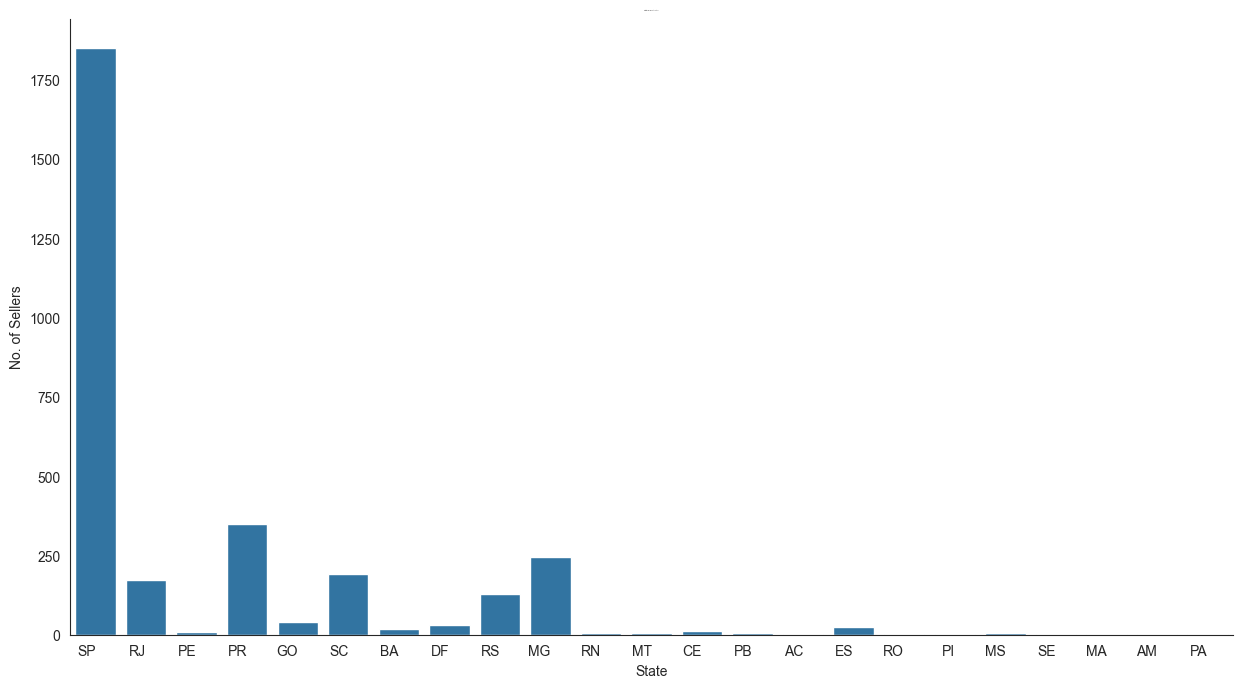

In [ ]:
plt.figure(figsize=(15,8))
plt.xticks(rotation=0, ha='right')
sns.countplot(x='seller_state', data=sellers)
plt.title('State Seller Distribution', fontsize=0)
plt.xlabel('State')
plt.ylabel('No. of Sellers')
sns.despine() # Thêm dòng này ở đây

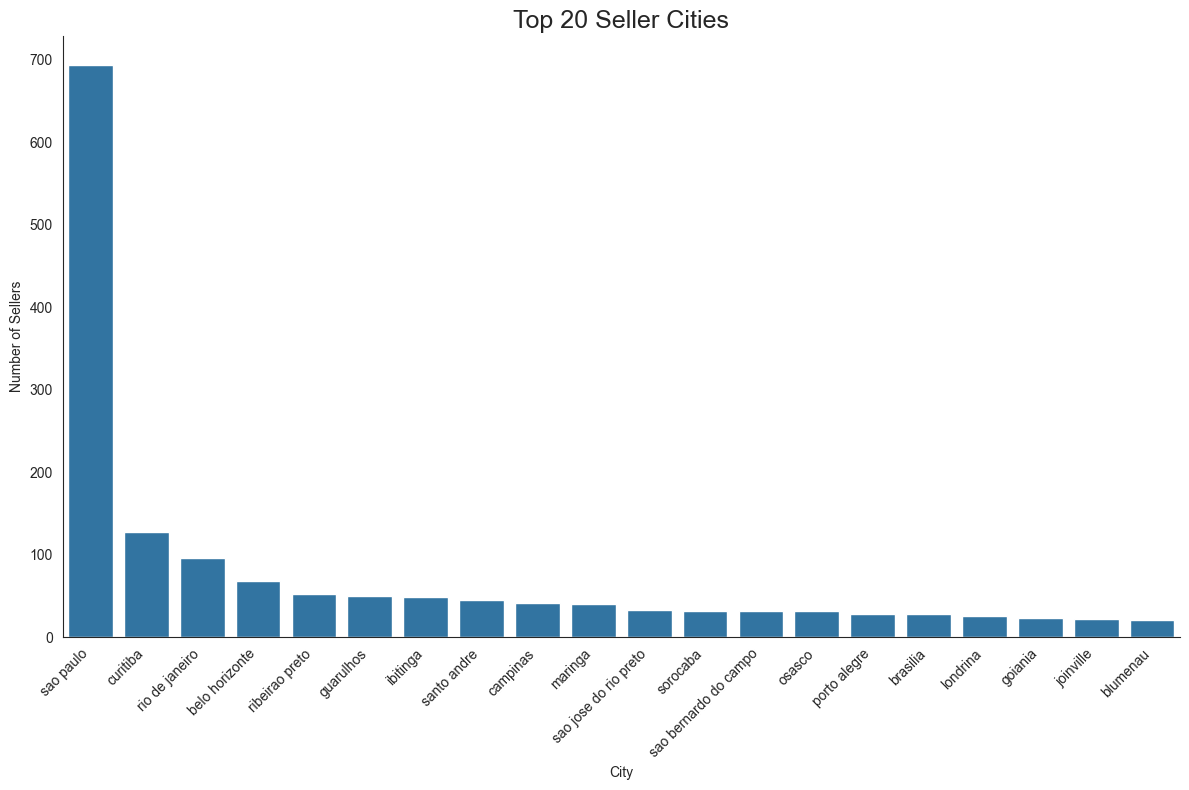

In [ ]:
top20 = sellers_eda['seller_city'].value_counts().head(20)
plt.figure(figsize=(12,8))
plt.rcParams['axes.grid'] = False

ax = sns.barplot(x=top20.index, y=top20.values)
ax.set_title('Top 20 Seller Cities', fontsize=18)
ax.set_xlabel('City')
ax.set_ylabel('Number of Sellers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sns.despine() # Thêm dòng này ở đây
plt.show()

In [ ]:
import matplotlib.colors as colors

### 4.1.3 Geography Visualization

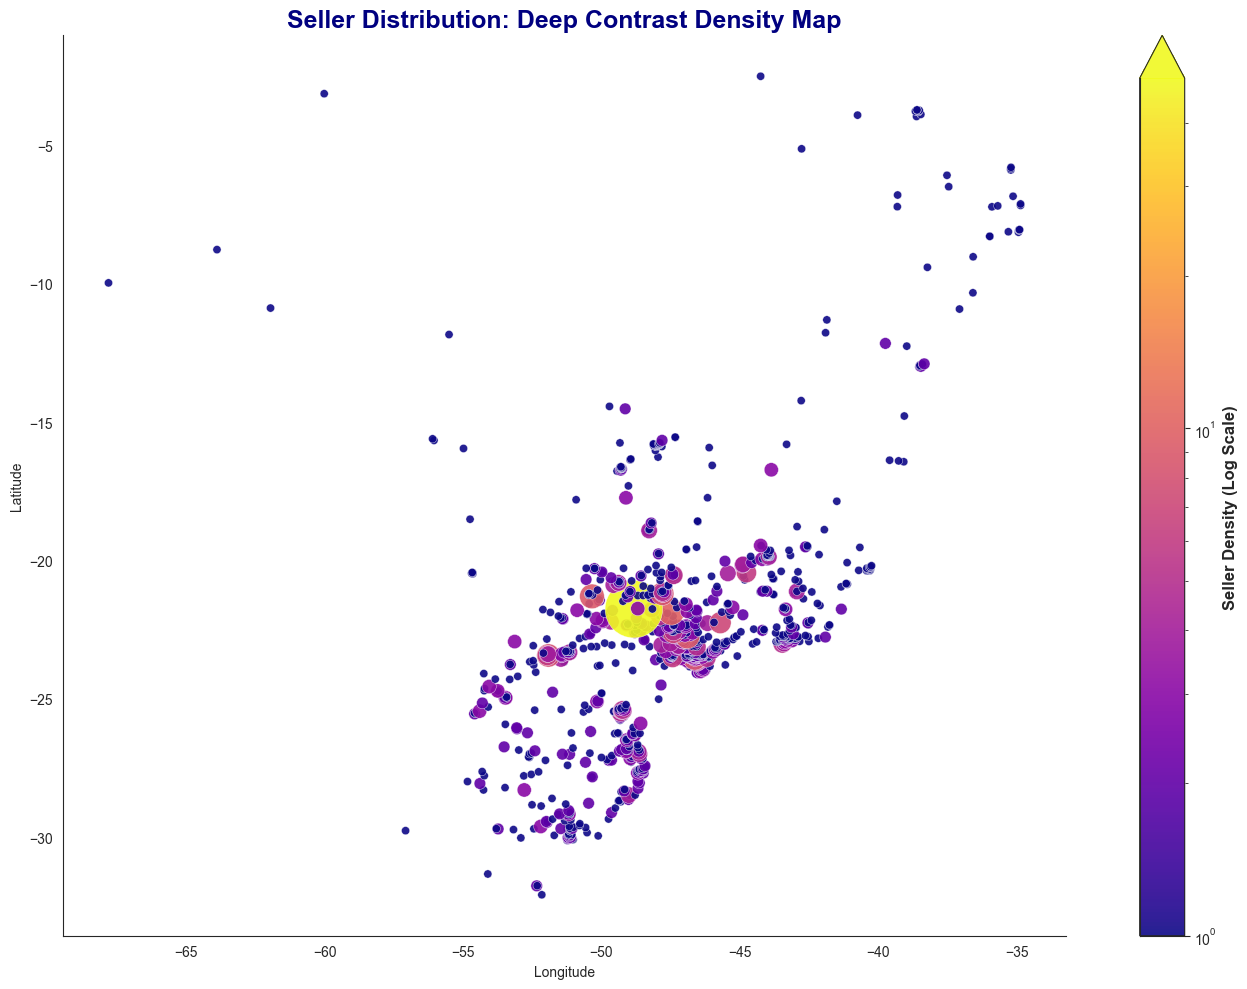

In [ ]:
geo_avg = geolocation.groupby('geolocation_zip_code_prefix')[[
    'geolocation_lat', 'geolocation_lng'
]].mean().reset_index()

# --- 2. Merge với dữ liệu Seller ---
sel_geo = sellers_eda.merge(
    geo_avg,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)
final_geo_counts = sel_geo.groupby(['geolocation_lat', 'geolocation_lng']).size().reset_index(name='count')

# --- 4. Vẽ biểu đồ ---
plt.figure(figsize=(15, 10))
sns.set_style('white') 

# Sử dụng final_geo_counts đã có cột 'count'
sc = plt.scatter(
    final_geo_counts['geolocation_lng'], 
    final_geo_counts['geolocation_lat'], 
    s=final_geo_counts['count'] * 35,          # Size to lên theo số lượng
    c=final_geo_counts['count'],              # Màu đậm theo số lượng
    norm=colors.LogNorm(vmin=1, vmax=final_geo_counts['count'].max()), 
    cmap='plasma',                             # Càng lớn màu xanh càng đậm (Navy)    
    alpha=0.9, 
    edgecolors='white', 
    linewidth=0.3
)

# Colorbar
cbar = plt.colorbar(sc, extend='max')
cbar.set_label('Seller Density (Log Scale)', fontsize=12, fontweight='bold')

# Tiêu đề và nhãn
plt.title('Seller Distribution: Deep Contrast Density Map', fontsize=18, fontweight='bold', color='navy')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Tinh chỉnh hiển thị
plt.grid(False)
sns.despine() 
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

### 4.1.4. Summary

In [ ]:
main_seller_profile = pd.DataFrame({
    "dimension": [
        "Top city",
        "Top state",
        "Top zip prefix"
    ],
    "dominant_group": [
        sellers_eda["seller_city"].fillna("Unknown").value_counts().idxmax(),
        sellers_eda["seller_state"].fillna("Unknown").value_counts().idxmax(),
        sellers_eda["seller_zip_code_prefix"].fillna("Unknown").value_counts().idxmax()
    ],
    "seller_count": [
        sellers_eda["seller_city"].fillna("Unknown").value_counts().max(),
        sellers_eda["seller_state"].fillna("Unknown").value_counts().max(),
        sellers_eda["seller_zip_code_prefix"].fillna("Unknown").value_counts().max()
    ]
})

main_seller_profile["percentage"] = round(
    main_seller_profile["seller_count"] / len(sellers_eda) * 100,
    2
)

main_seller_profile

,dimension,dominant_group,seller_count,percentage
0,Top city,sao paulo,694,22.42
1,Top state,SP,1849,59.74
2,Top zip prefix,14940,49,1.58


## 4.2 Customers & Geolocation

In [ ]:
customers_eda = customers.copy()
geolocation_eda = geolocation.copy()

### 4.2.1 Total customers

In [ ]:
customer_summary = pd.DataFrame({
    "metric": ["Total rows", "Unique customers", "Missing customer_id"],
    "value": [
        len(customers_eda),
        customers_eda["customer_id"].nunique(),
        customers_eda["customer_id"].isna().sum()
    ]
})

customer_summary

,metric,value
0,Total rows,99441
1,Unique customers,99441
2,Missing customer_id,0


### 4.2.2 Customer Location Distribution

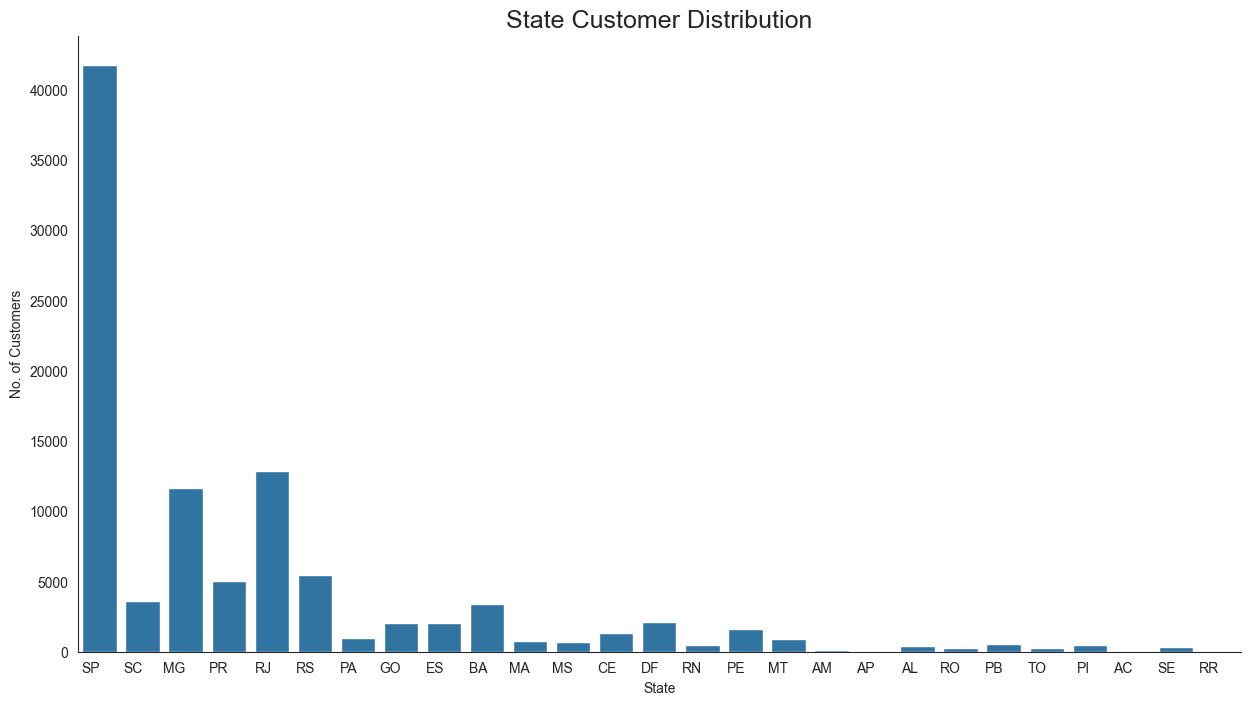

In [ ]:
plt.figure(figsize=(15,8))
plt.xticks(ha='right')
sns.countplot(x='customer_state', data=customers)
plt.title('State Customer Distribution', fontsize=18)
plt.xlabel('State')
plt.ylabel('No. of Customers')
sns.despine()

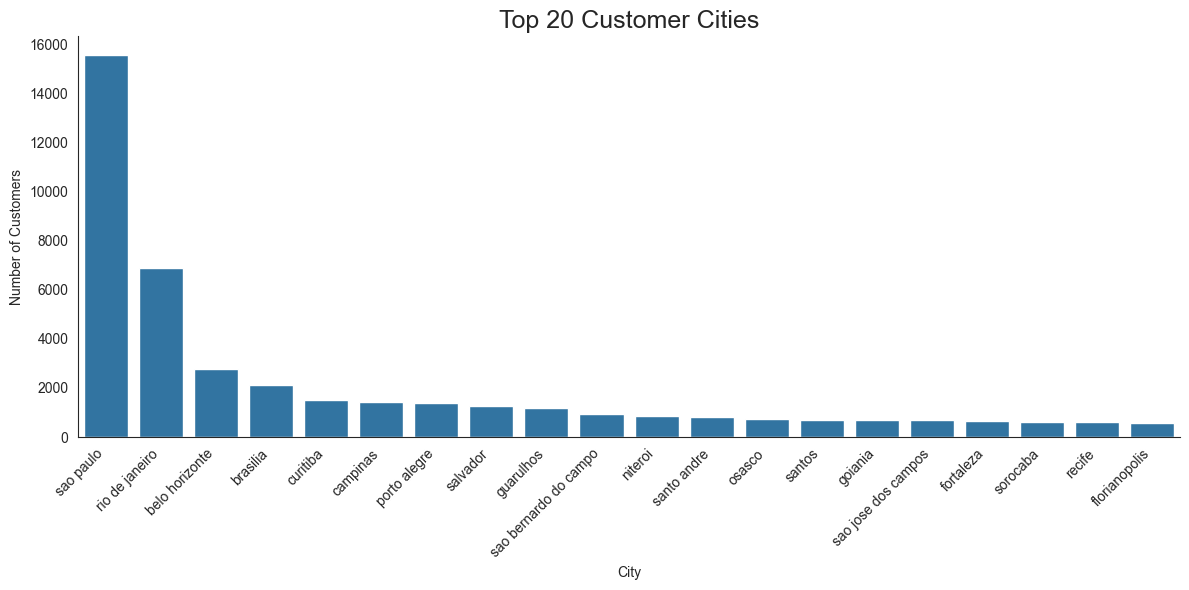

In [ ]:
top20 = customers_eda['customer_city'].value_counts().head(20)
plt.figure(figsize=(12,6))
ax = sns.barplot(x=top20.index, y=top20.values)
ax.set_title('Top 20 Customer Cities', fontsize=18)
ax.set_xlabel('City')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sns.despine() # Thêm dòng này ở đây
plt.show()


### 4.2.3 Geography Visualization

In [ ]:
geo_avg = (
    geolocation
    .groupby('geolocation_zip_code_prefix')[
        ['geolocation_lat', 'geolocation_lng']
    ]
    .mean()
    .reset_index()
)

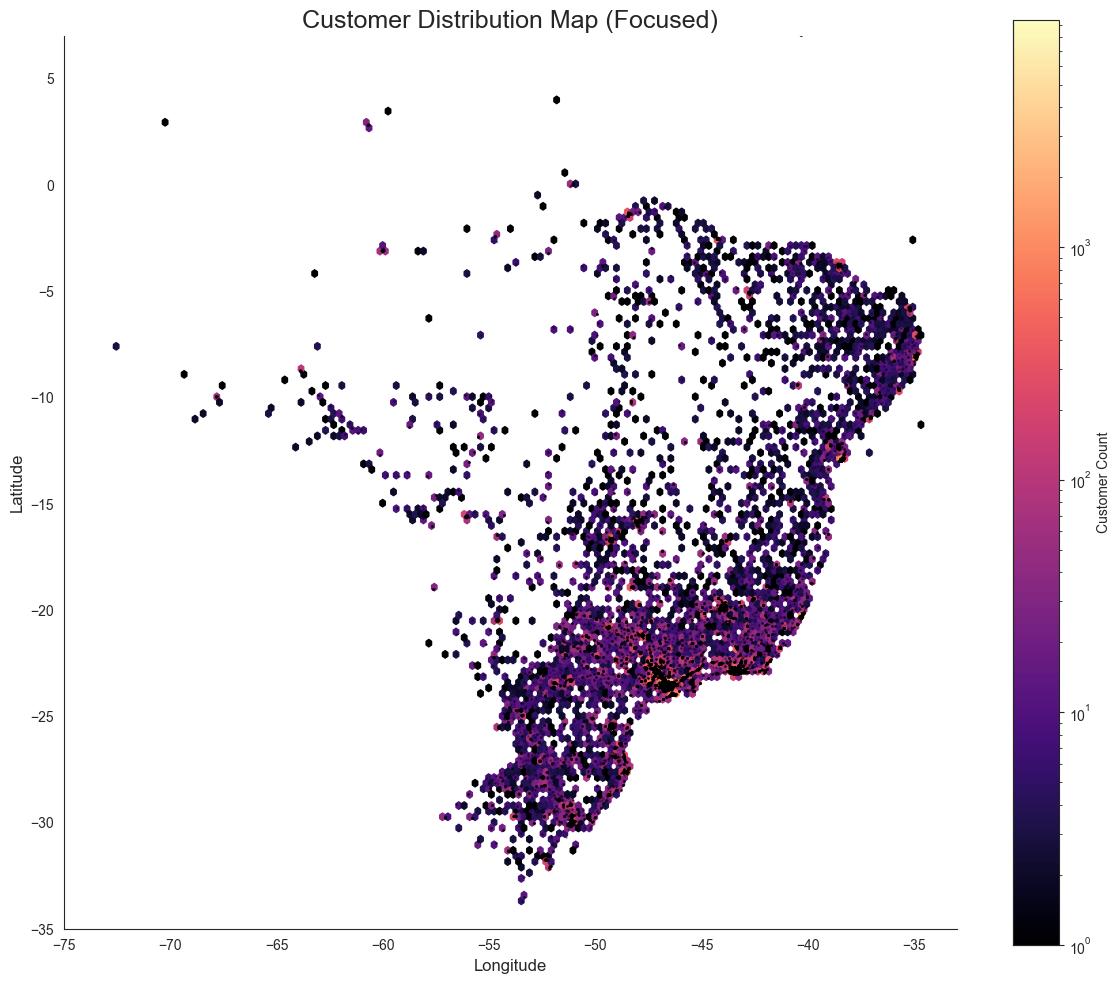

In [ ]:
# Merge customer data with geolocation
cust_geo = customers.merge(
    geo_avg,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

# 2. Thiết lập biểu đồ
plt.figure(figsize=(12, 10))
sns.set_style('white')

# Vẽ bản đồ mật độ dạng lục giác (Hexbin)
# Tăng gridsize lên (ví dụ 250) để khi zoom vào hình ảnh vẫn sắc nét
hb = plt.hexbin(
    cust_geo['geolocation_lng'],
    cust_geo['geolocation_lat'],
    gridsize=250, 
    cmap='magma',
    bins='log',
    mincnt=1
)
# Thêm thanh chú thích màu sắc
plt.colorbar(hb, label='Customer Count')

# Vẽ đè các điểm chấm nhỏ để thấy rõ sự phân tán chi tiết
plt.scatter(
    cust_geo['geolocation_lng'],
    cust_geo['geolocation_lat'],
    s=0.3,          # Kích thước điểm cực nhỏ để tránh bị rối
    alpha=0.1,      # Độ trong suốt thấp
    color='black'
)

# 3. THIẾT LẬP PHÓNG TO (ZOOM) VÀO KHU VỰC TRUNG TÂM
# Các tọa độ này tập trung vào Brazil, loại bỏ các điểm thừa (outliers)
plt.xlim(-75, -33)  # Thu hẹp trục X (Longitude)
plt.ylim(-35, 7)    # Thu hẹp trục Y (Latitude)

# Tiêu đề và nhãn
plt.title('Customer Distribution Map (Focused)', fontsize=18)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Giữ đúng tỷ lệ hình dạng địa lý (không bị méo bản đồ)
plt.gca().set_aspect('equal', adjustable='box')

# Loại bỏ đường viền phía trên và bên phải cho sạch sẽ
sns.despine()

plt.tight_layout()
plt.show()

### 4.2.4 Summary

In [ ]:
main_customer_profile = pd.DataFrame({
    "dimension": [
        "Top city",
        "Top state",
        "Top zip prefix"
    ],
    "dominant_group": [
        customers_eda["customer_city"].fillna("Unknown").value_counts().idxmax(),
        customers_eda["customer_state"].fillna("Unknown").value_counts().idxmax(),
        customers_eda["customer_zip_code_prefix"].fillna("Unknown").value_counts().idxmax()
    ],
    "customer_count": [
        customers_eda["customer_city"].fillna("Unknown").value_counts().max(),
        customers_eda["customer_state"].fillna("Unknown").value_counts().max(),
        customers_eda["customer_zip_code_prefix"].fillna("Unknown").value_counts().max()
    ]
})

main_customer_profile["percentage"] = round(
    main_customer_profile["customer_count"] / len(customers_eda) * 100,
    2
)

main_customer_profile

,dimension,dominant_group,customer_count,percentage
0,Top city,sao paulo,15540,15.63
1,Top state,SP,41746,41.98
2,Top zip prefix,22790,142,0.14


## 4.3 Orders

In [ ]:
orders_eda = orders.copy()

### 4.3.1 Total orders

In [ ]:
total_orders = orders_eda["order_id"].nunique()
total_rows = len(orders_eda)

order_summary = pd.DataFrame({
    "metric": ["Total rows", "Unique orders", "Missing order_id"],
    "value": [total_rows, total_orders, orders_eda["order_id"].isna().sum()]
})

order_summary

,metric,value
0,Total rows,99441
1,Unique orders,99441
2,Missing order_id,0


### 4.3.2 Order status

In [ ]:
order_status_dist = (
    orders_eda["order_status"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)

order_status_dist.columns = ["order_status", "order_count"]
order_status_dist["percentage"] = round(order_status_dist["order_count"] / order_status_dist["order_count"].sum() * 100, 2)

order_status_dist

,order_status,order_count,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


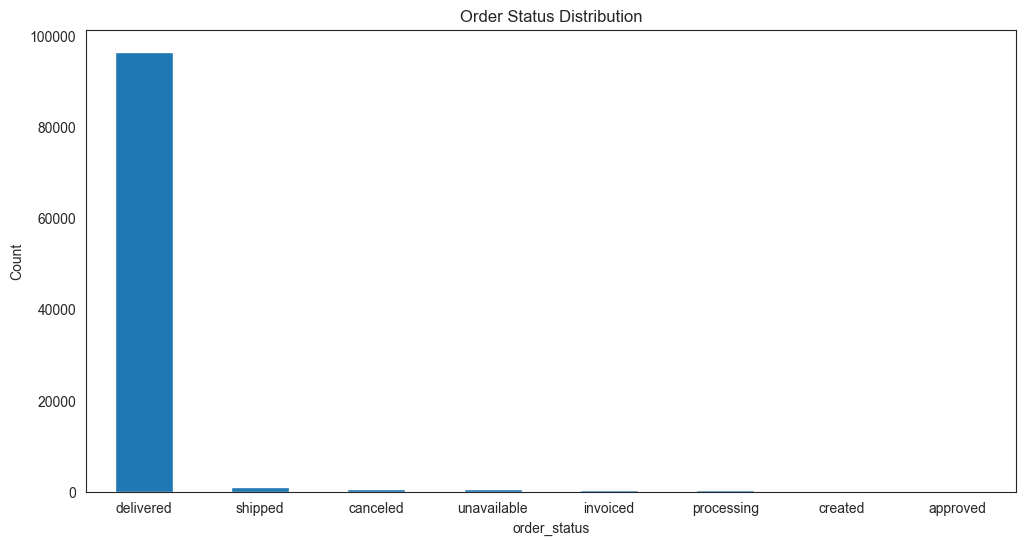

In [ ]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

plt.figure(figsize=(12, 6))

# Bar chart — Order status distribution
order_status_dist = orders['order_status'].value_counts()
order_status_dist.plot(kind='bar')
plt.title('Order Status Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### 4.3.3 Order time

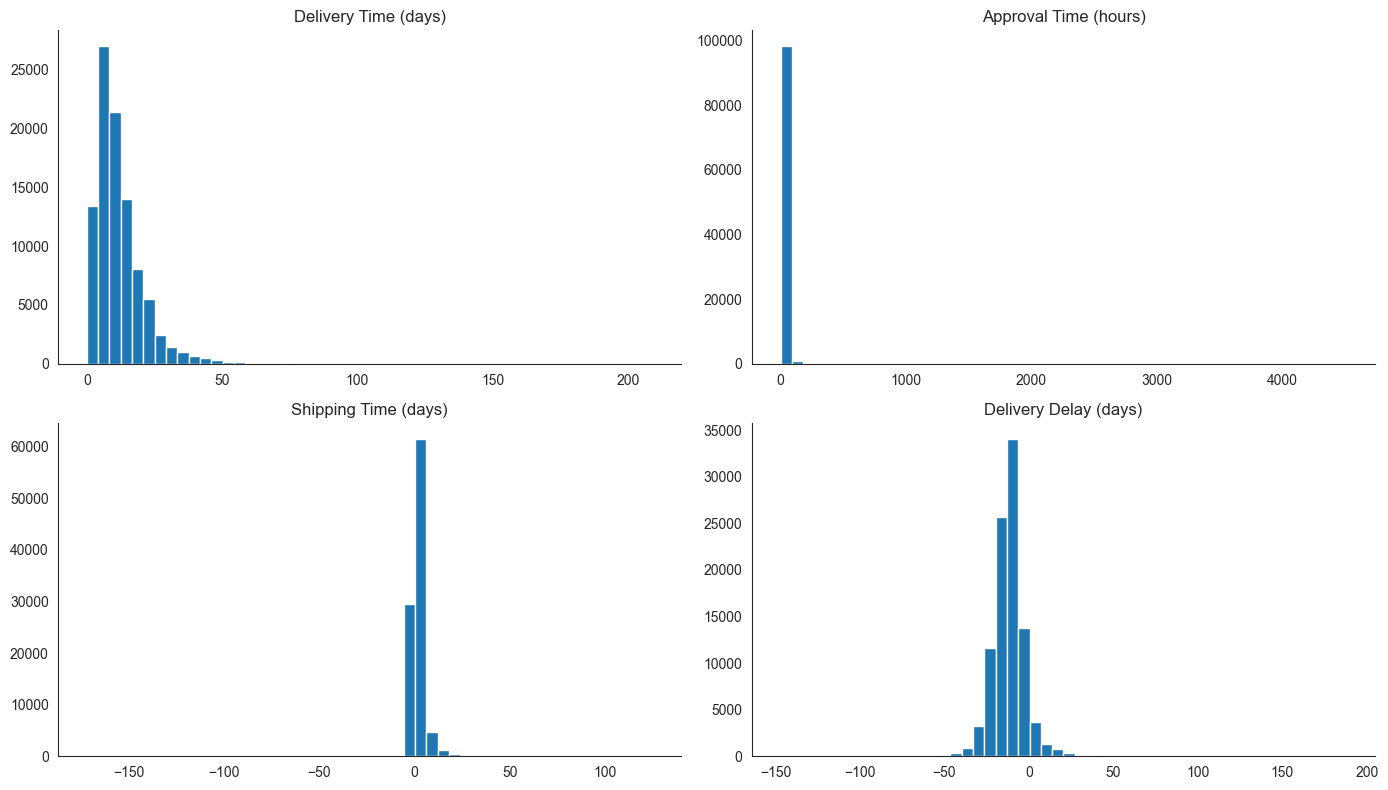

In [ ]:
orders['delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['approval_time'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600
orders['shipping_time'] = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.days
orders['delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plt.rcParams['axes.grid'] = False

axes[0, 0].hist(orders['delivery_time'].dropna(), bins=50)
axes[0, 0].set_title('Delivery Time (days)')

axes[0, 1].hist(orders['approval_time'].dropna(), bins=50)
axes[0, 1].set_title('Approval Time (hours)')

axes[1, 0].hist(orders['shipping_time'].dropna(), bins=50)
axes[1, 0].set_title('Shipping Time (days)')

axes[1, 1].hist(orders['delay'].dropna(), bins=50)
axes[1, 1].set_title('Delivery Delay (days)')

sns.despine() # Thêm dòng này ở đây

plt.tight_layout()
plt.show()

## 4.4 Products

In [ ]:
products_eda = products.copy()

### 4.4.1 Total products

In [ ]:
n_products = products_eda["product_id"].nunique()
n_rows_products = len(products_eda)

product_summary = pd.DataFrame({
    "metric": ["Total rows in products", "Unique products"],
    "value": [n_rows_products, n_products]
})

product_summary

,metric,value
0,Total rows in products,32951
1,Unique products,32951


### 4.4.2 Product Categories Analysis

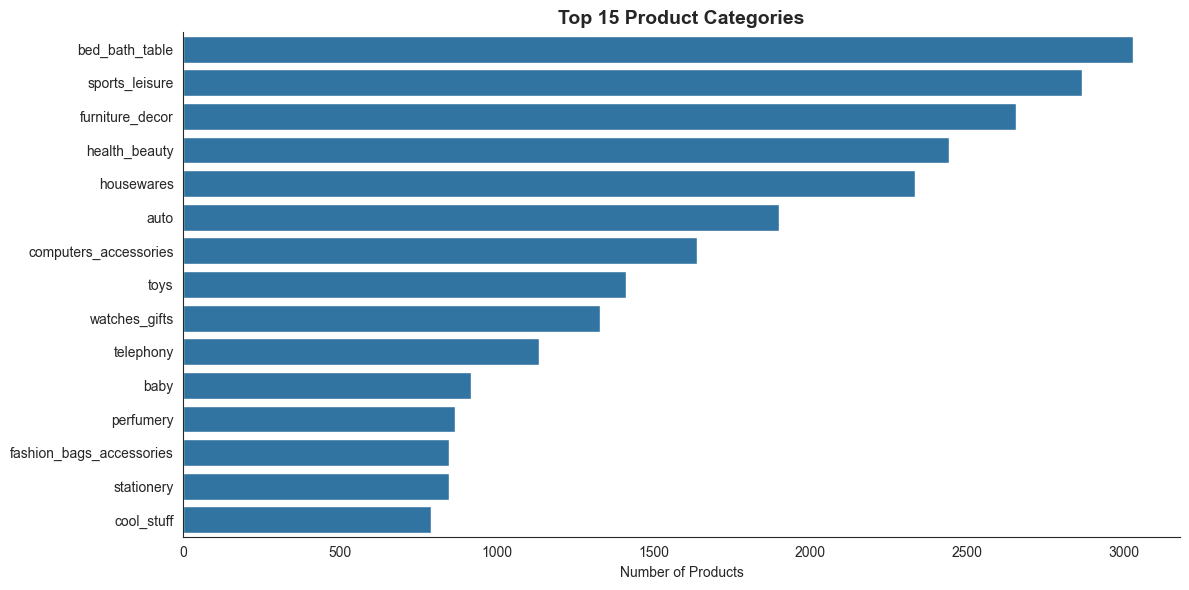

In [ ]:
top_cat = (products_eda["product_category_name"].value_counts().head(15).sort_values(ascending=False))

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_cat.values,
    y=top_cat.index
)

plt.title("Top 15 Product Categories", fontsize=14, weight='bold')
plt.xlabel("Number of Products")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

### 4.4.3. Products Characteristics

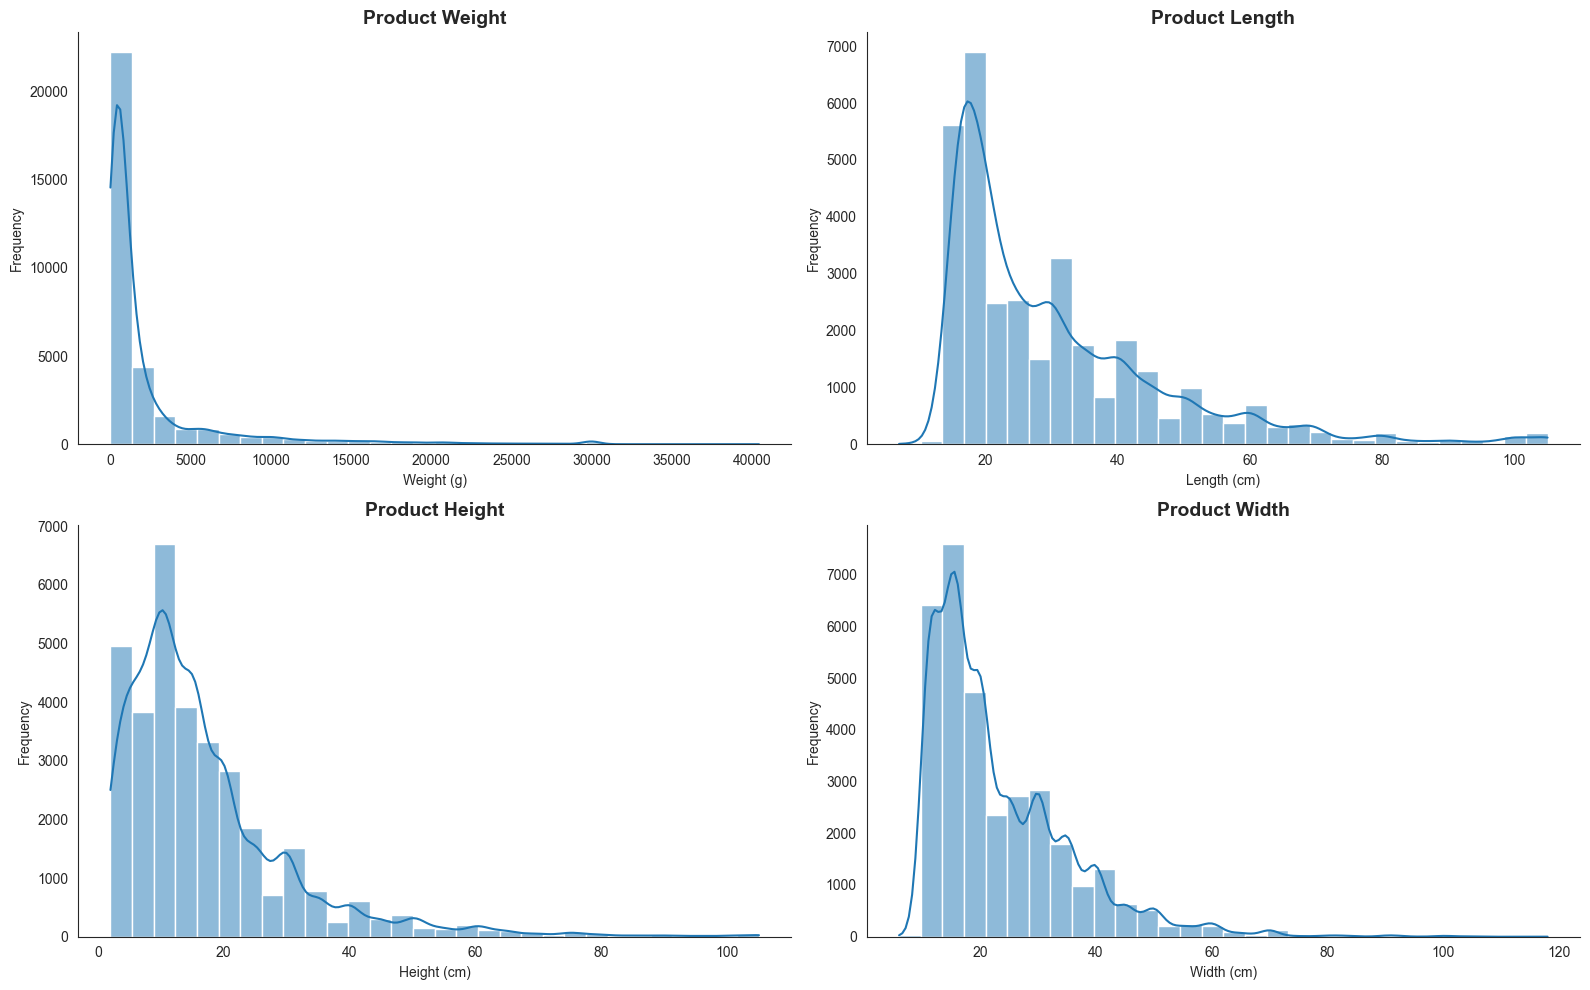

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# PRODUCT WEIGHT
sns.histplot(
    products_eda["product_weight_g"],
    bins=30,
    kde=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Product Weight", fontsize=14, weight='bold')
axes[0, 0].set_xlabel("Weight (g)")
axes[0, 0].set_ylabel("Frequency")


# PRODUCT LENGTH
sns.histplot(
    products_eda["product_length_cm"],
    bins=30,
    kde=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Product Length", fontsize=14, weight='bold')
axes[0, 1].set_xlabel("Length (cm)")
axes[0, 1].set_ylabel("Frequency")


# PRODUCT HEIGHT
sns.histplot(
    products_eda["product_height_cm"],
    bins=30,
    kde=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Product Height", fontsize=14, weight='bold')
axes[1, 0].set_xlabel("Height (cm)")
axes[1, 0].set_ylabel("Frequency")


# PRODUCT WIDTH
sns.histplot(
    products_eda["product_width_cm"],
    bins=30,
    kde=True,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Product Width", fontsize=14, weight='bold')
axes[1, 1].set_xlabel("Width (cm)")
axes[1, 1].set_ylabel("Frequency")


sns.despine()
plt.tight_layout()
plt.show()

## 4.5 Transactions

In [ ]:
payments_eda = payments.copy()

C:\Users\admin\AppData\Local\Temp\ipykernel_28888\4099855415.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


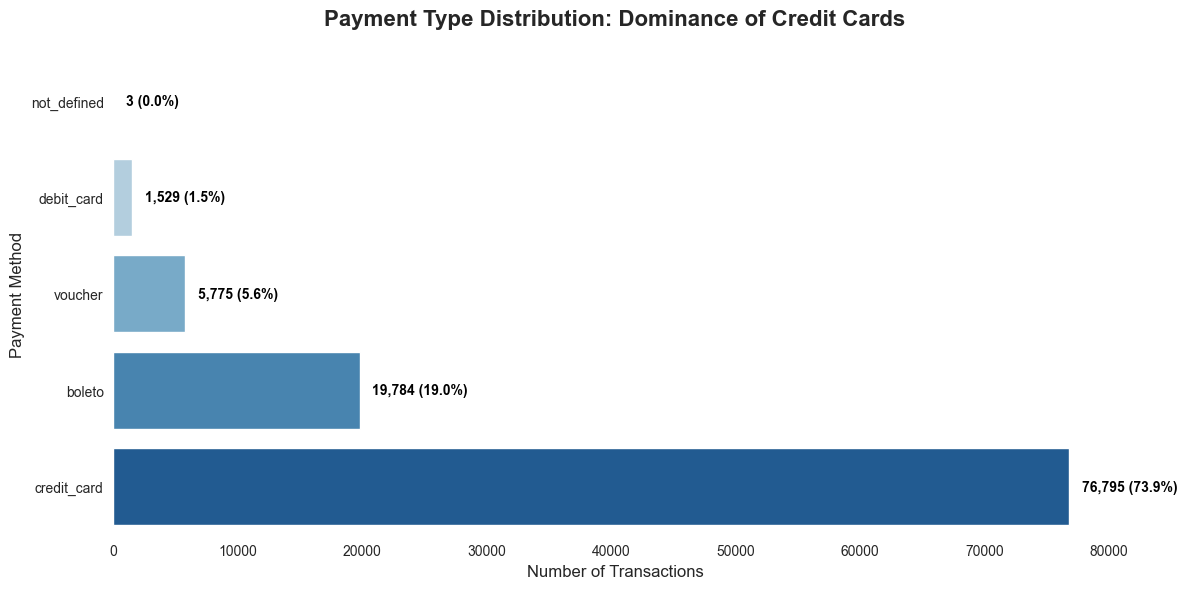

In [ ]:
# Sắp xếp dữ liệu giảm dần để biểu đồ trông gọn gàng
payment_counts = payments_eda["payment_type"].fillna("Unknown").value_counts().sort_values(ascending=True)

plt.figure(figsize=(12, 6))

# Sử dụng tông màu Blues đồng bộ với báo cáo của bạn
# 'Blues_d' tạo dải màu đậm dần cho các thanh có giá trị lớn hơn
ax = sns.barplot(
    x=payment_counts.values, 
    y=payment_counts.index, 
    palette="Blues"
)

# Thêm nhãn số lượng và tỷ lệ % ngay trên đầu mỗi thanh
total = payment_counts.sum()
for i, v in enumerate(payment_counts.values):
    percentage = f"({v/total:.1%})"
    ax.text(v + (total*0.01), i, f"{v:,} {percentage}", color='black', va='center', fontweight='bold')

# Tùy chỉnh tiêu đề và nhãn
plt.title("Payment Type Distribution: Dominance of Credit Cards", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of Transactions", fontsize=12)
plt.ylabel("Payment Method", fontsize=12)

# Loại bỏ khung thừa để biểu đồ thoáng hơn
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [ ]:
items_eda = items.copy()

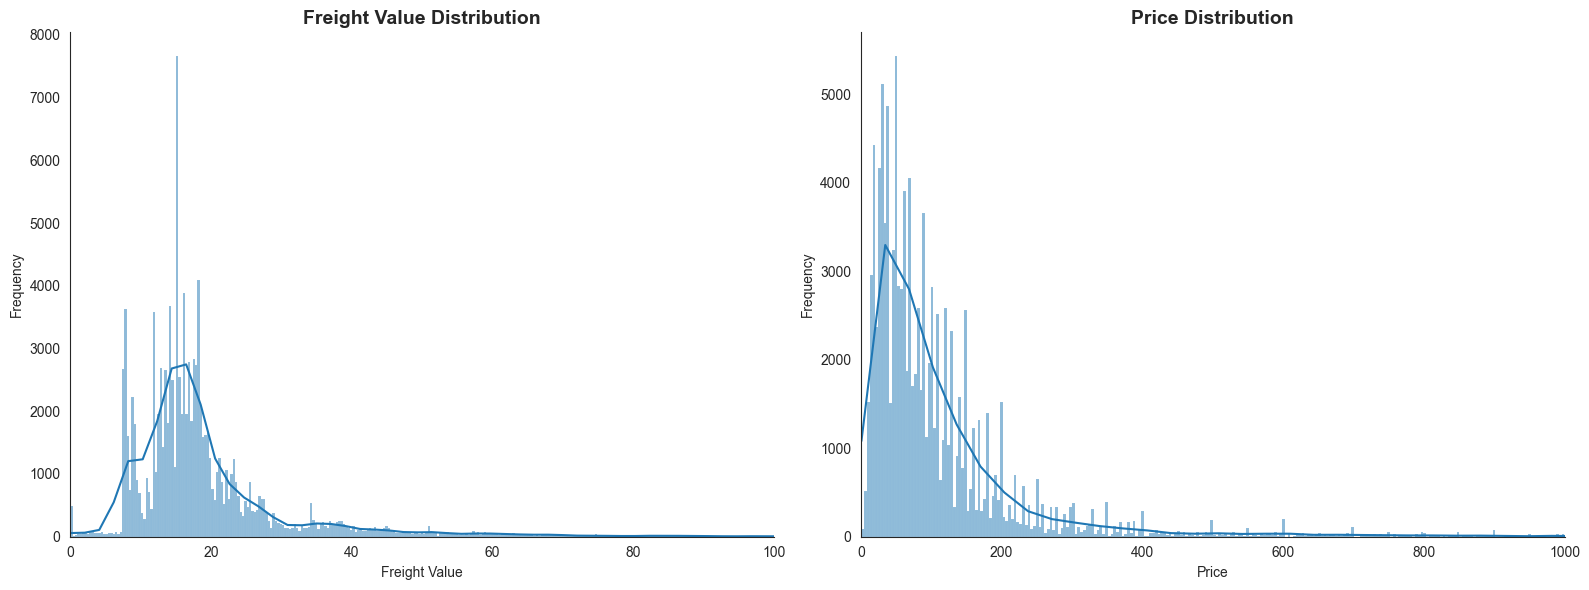

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Freight Value Distribution
sns.histplot(items_eda["freight_value"], kde=True, ax=axes[0])
axes[0].set_title("Freight Value Distribution", fontsize=14, weight="bold")
axes[0].set_xlabel("Freight Value")
axes[0].set_ylabel("Frequency")

# Thu hẹp trục X cho Freight: Hầu hết tập trung dưới 100
axes[0].set_xlim(0, 100) 

# 2. Price Distribution
sns.histplot(items_eda["price"], kde=True, ax=axes[1])
axes[1].set_title("Price Distribution", fontsize=14, weight="bold")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Frequency")

# Thu hẹp trục X cho Price: Hầu hết tập trung dưới 1000
axes[1].set_xlim(0, 1000)

sns.despine()
plt.tight_layout()
plt.show()

# 5. Target Analysis & Feature Exploration for Modeling

## 5.1 Order & GMV Analysis


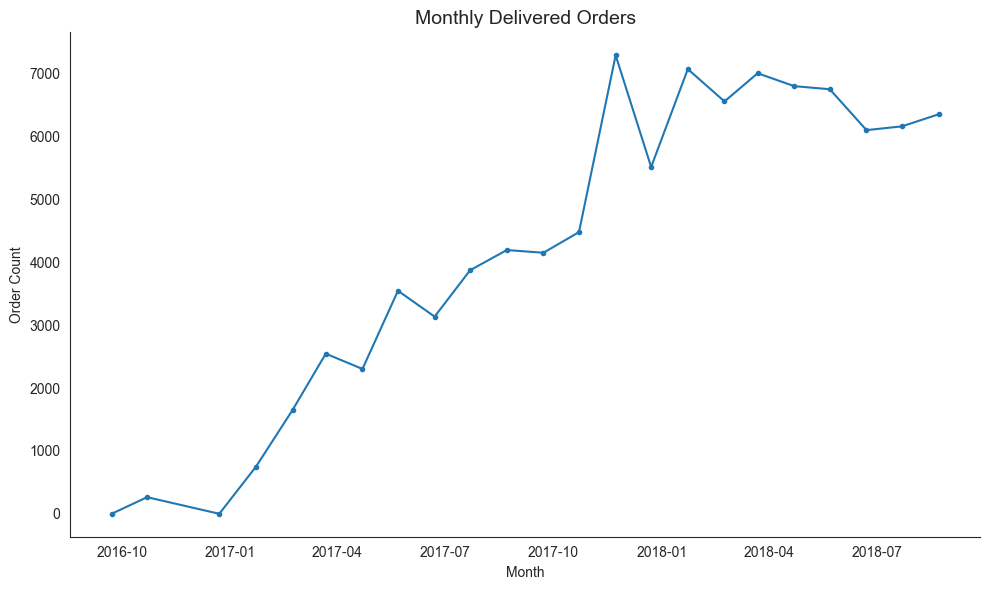

In [ ]:
plt.figure(figsize=(10, 6))

# Line chart - Monthly delivered orders
monthly_delivered = orders[orders['order_status'] == 'delivered'].groupby('month').size()

# 2. Vẽ biểu đồ (bỏ title trong hàm plot để dùng plt.title cho linh hoạt)
monthly_delivered.plot(kind='line', marker='.')

# 3. Chỉnh tiêu đề và nhãn
plt.title('Monthly Delivered Orders', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Order Count')

plt.xticks(rotation=0)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout() # Tự động căn chỉnh để không mất lề
plt.show()

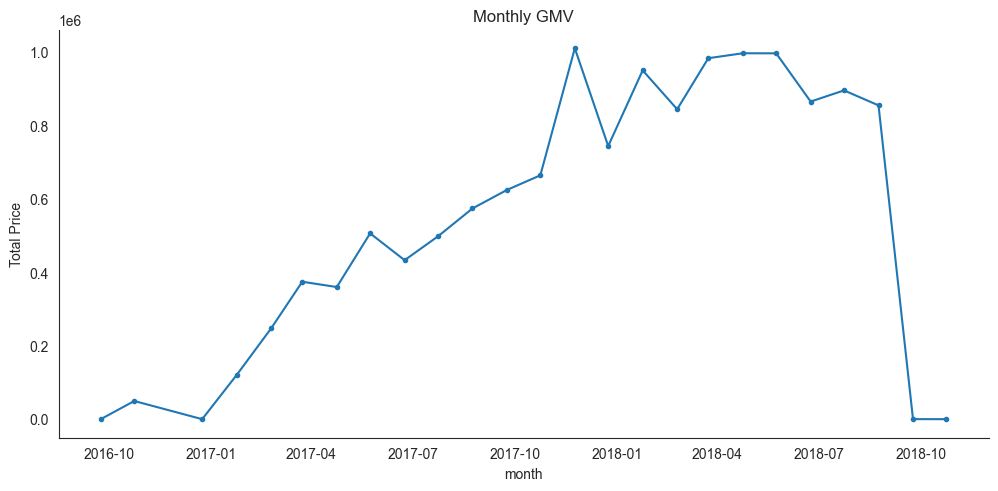

In [ ]:
plt.figure(figsize=(12, 6))

# Cần merge orders với items để lấy giá tiền
order_items_val = items.groupby('order_id')['price'].sum().reset_index()
orders_gmv = orders.merge(order_items_val, on='order_id', how='left')
monthly_gmv = orders_gmv.groupby('month')['price'].sum()

monthly_gmv.plot(kind='line', marker='.', title='Monthly GMV')

# Thêm gridline
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=0)
plt.ylabel('Total Price')
plt.show()

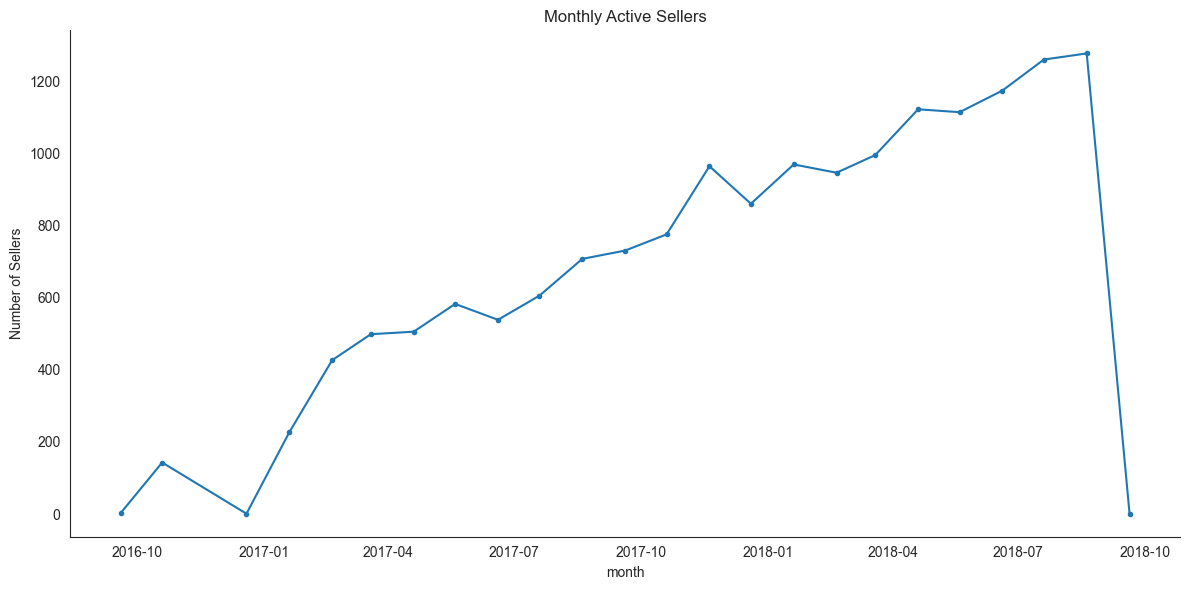

In [ ]:
plt.figure(figsize=(12, 6))

# Line chart – Monthly active sellers
monthly_sellers = orders.merge(items[['order_id', 'seller_id']], on='order_id')
monthly_active_sellers = monthly_sellers.groupby('month')['seller_id'].nunique()

# 2. Vẽ biểu đồ với các thông số bạn đã chọn
monthly_active_sellers.plot(kind='line', marker='.',title='Monthly Active Sellers')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 4. Chỉnh nhãn trục x nằm ngang
plt.xticks(rotation=0)

# 5. Thêm nhãn trục y cho rõ ràng
plt.ylabel('Number of Sellers')

plt.tight_layout()
plt.show()

- Insight: The platform exhibits a strong and consistent upward trend in Order Count, GMV, and Active Sellers from late 2016 through mid-2018, indicating a healthy scaling phase. A significant spike is observed in November 2017, corresponding to Black Friday, which served as a major growth driver for the period.

- Note on Data Incompleteness: The sharp decline observed in September 2018 across all metrics is due to partial data collection for the final month (data ends in early September) and the delivery time lag (many late-August orders had not yet reached 'delivered' status at the time of extraction). This drop represents a data cutoff, not a decline in business performance.

## 5.2 Seller Performance Distribution

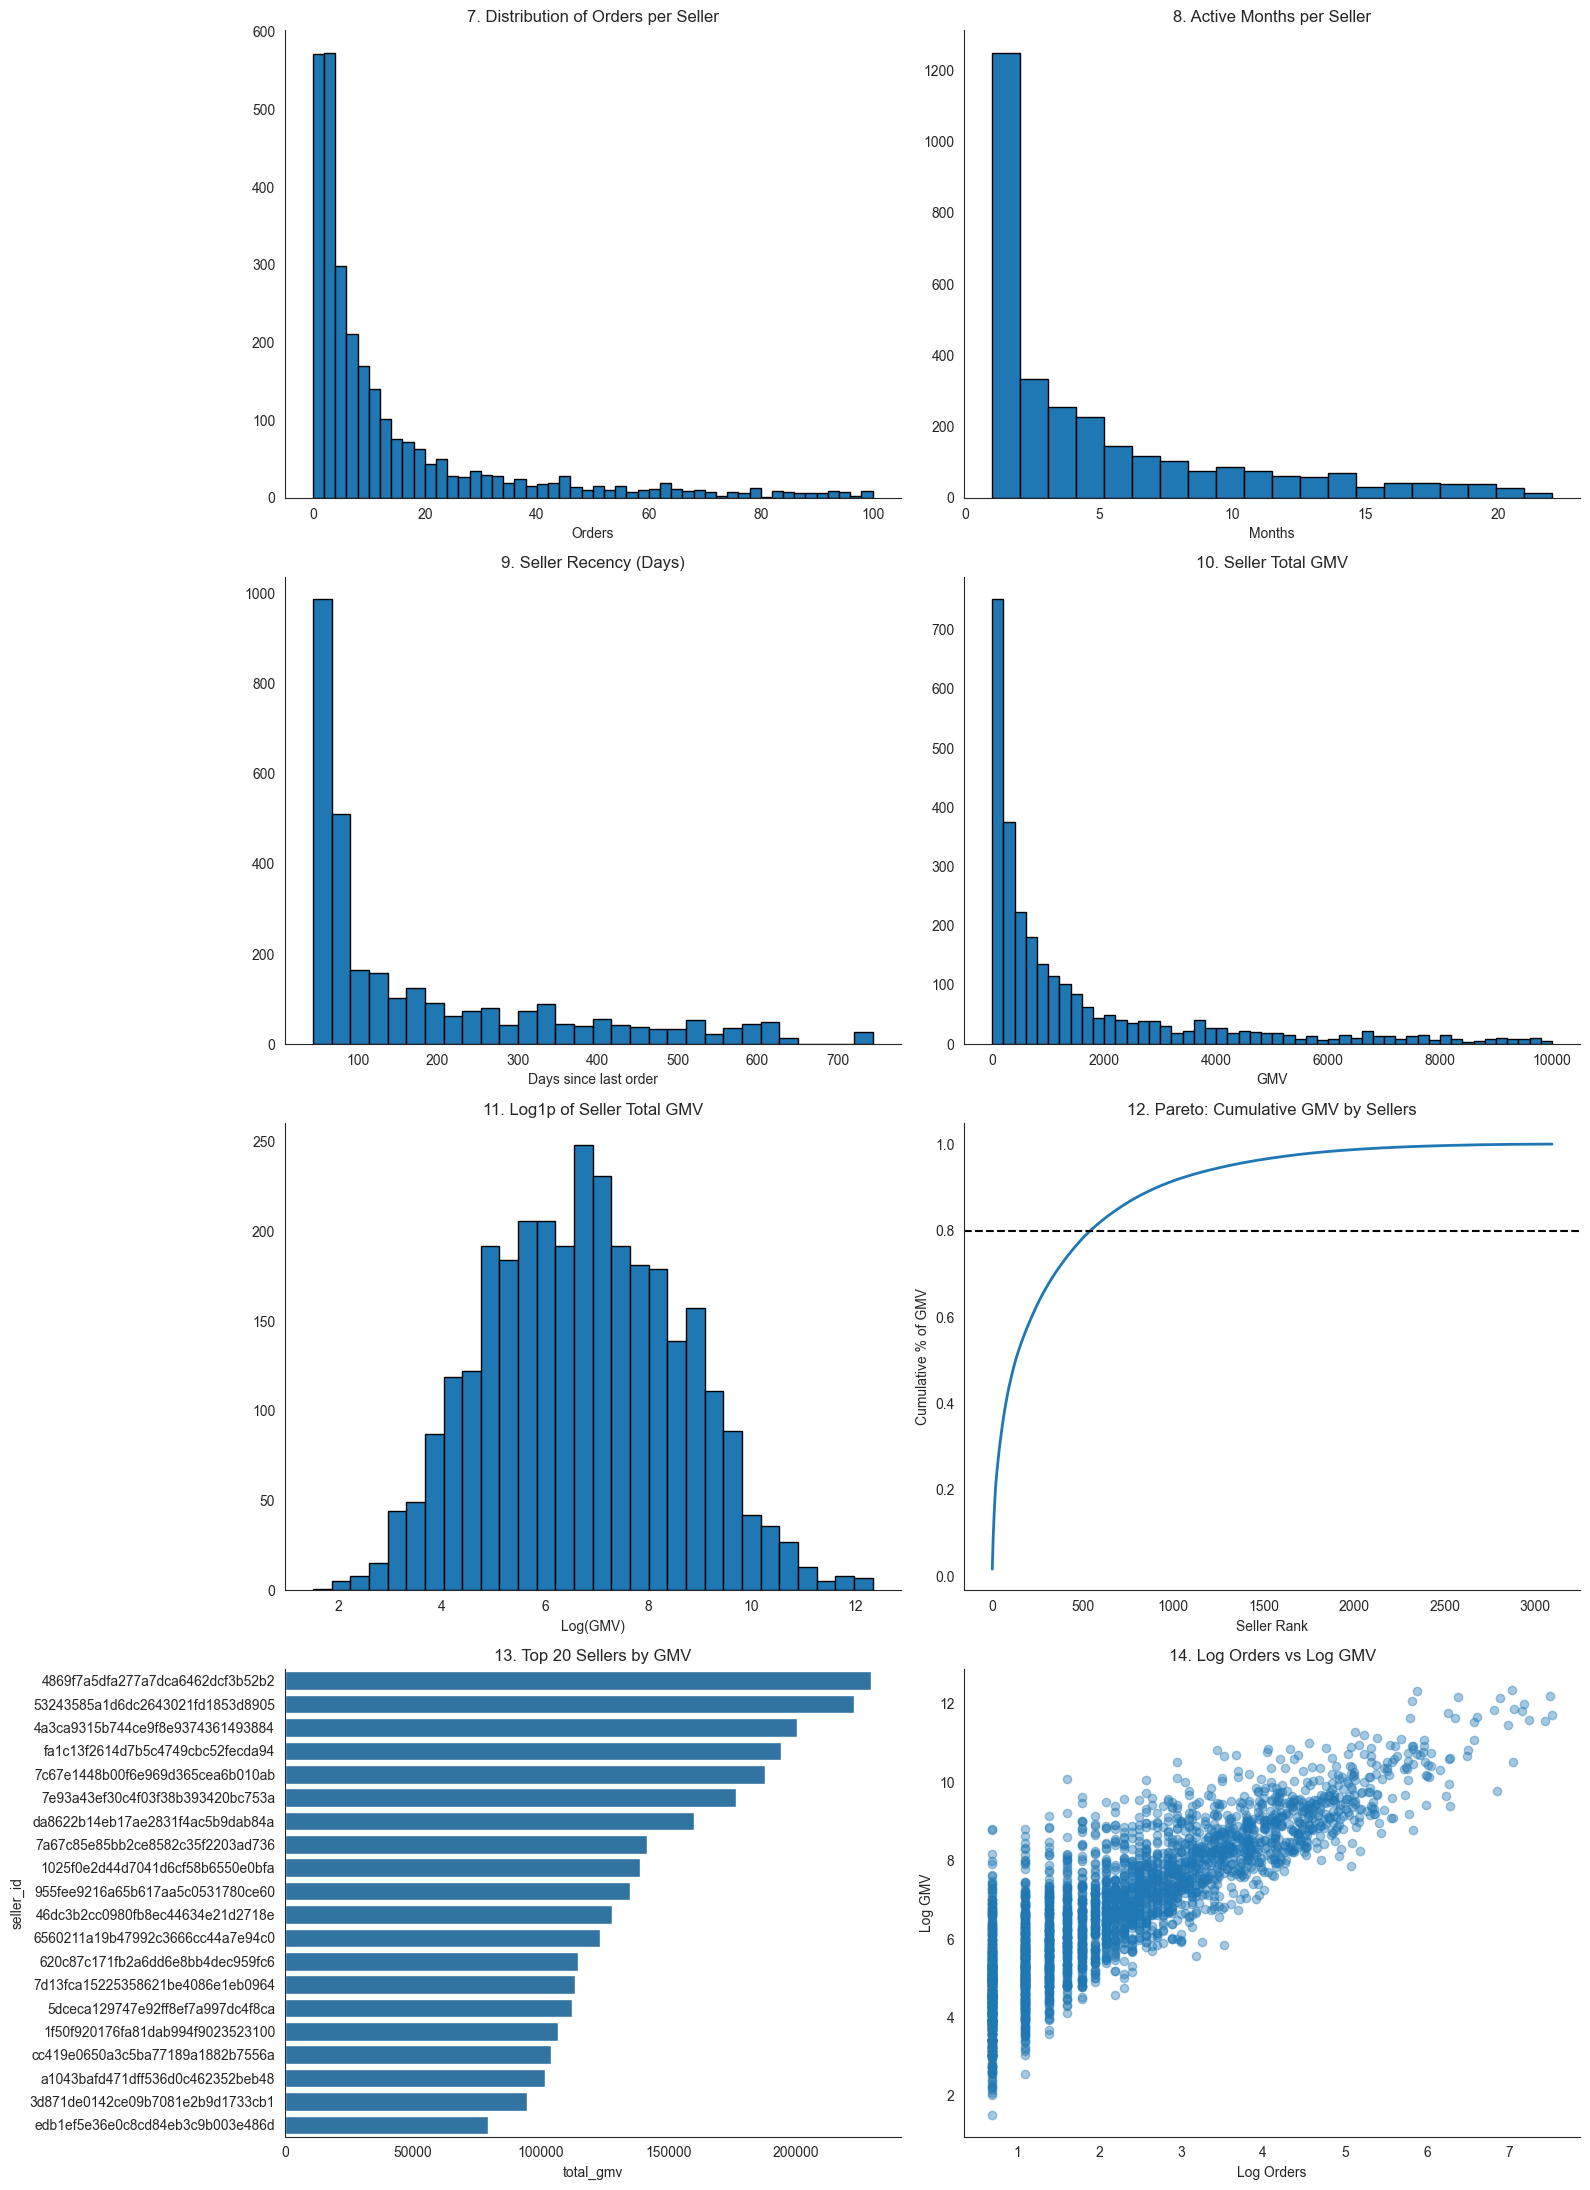

In [ ]:
seller_stats = items.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    total_gmv=('price', 'sum')
).reset_index()

active_months = monthly_sellers.groupby('seller_id')['month'].nunique()

max_date = orders['order_purchase_timestamp'].max()
seller_recency_df = orders.merge(items[['order_id', 'seller_id']], on='order_id')
seller_recency = seller_recency_df.groupby('seller_id')['order_purchase_timestamp'].max().apply(lambda x: (max_date - x).days)

seller_sorted = seller_stats.sort_values('total_gmv', ascending=False)
seller_sorted['cum_gmv'] = seller_sorted['total_gmv'].cumsum() / seller_sorted['total_gmv'].sum()

# --- Vẽ biểu đồ dạng lưới 4 hàng x 2 cột ---
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
plt.subplots_adjust(hspace=0.4)

# 7. Histogram — Orders per seller
axes[0, 0].hist(seller_stats['total_orders'], bins=50, range=(0, 100), edgecolor='black')
axes[0, 0].set_title('7. Distribution of Orders per Seller')
axes[0, 0].set_xlabel('Orders')

# 8. Histogram — Active months per seller
axes[0, 1].hist(active_months, bins=20, edgecolor='black')
axes[0, 1].set_title('8. Active Months per Seller')
axes[0, 1].set_xlabel('Months')

# 9. Histogram — Recency days
axes[1, 0].hist(seller_recency, bins=30,edgecolor='black')
axes[1, 0].set_title('9. Seller Recency (Days)')
axes[1, 0].set_xlabel('Days since last order')

# 10. Histogram — Seller total GMV
axes[1, 1].hist(seller_stats['total_gmv'], bins=50, range=(0, 10000), edgecolor='black')
axes[1, 1].set_title('10. Seller Total GMV')
axes[1, 1].set_xlabel('GMV')

# 11. Histogram — log1p(seller total GMV)
axes[2, 0].hist(np.log1p(seller_stats['total_gmv']), bins=30, edgecolor='black')
axes[2, 0].set_title('11. Log1p of Seller Total GMV')
axes[2, 0].set_xlabel('Log(GMV)')

# 12. Pareto chart — Cumulative GMV by sellers
axes[2, 1].plot(range(len(seller_sorted)), seller_sorted['cum_gmv'], linewidth=2)
axes[2, 1].axhline(y=0.8, color='black', linestyle='--')
axes[2, 1].set_title('12. Pareto: Cumulative GMV by Sellers')
axes[2, 1].set_xlabel('Seller Rank')
axes[2, 1].set_ylabel('Cumulative % of GMV')

# 13. Horizontal bar chart — Top 20 sellers by GMV
top_20_sellers = seller_sorted.head(20)
sns.barplot(data=top_20_sellers, x='total_gmv', y='seller_id', ax=axes[3, 0])
axes[3, 0].set_title('13. Top 20 Sellers by GMV')

# 14. Scatter plot — log orders vs log GMV
axes[3, 1].scatter(np.log1p(seller_stats['total_orders']), np.log1p(seller_stats['total_gmv']), alpha=0.4)
axes[3, 1].set_title('14. Log Orders vs Log GMV')
axes[3, 1].set_xlabel('Log Orders')
axes[3, 1].set_ylabel('Log GMV')

sns.despine()

plt.tight_layout()
plt.show()

- Insight: Seller performance strictly follows the Pareto Principle (80/20), where a small group of "Power Sellers" contributes the majority of the platform's total revenue. Most sellers are small-scale with low order frequency and short active lifespans, suggesting high market competitiveness or churn at the bottom tier. The log-transformed distributions reveal that while the majority of sellers have limited scale, their growth in GMV is highly correlated with their ability to increase order volume.

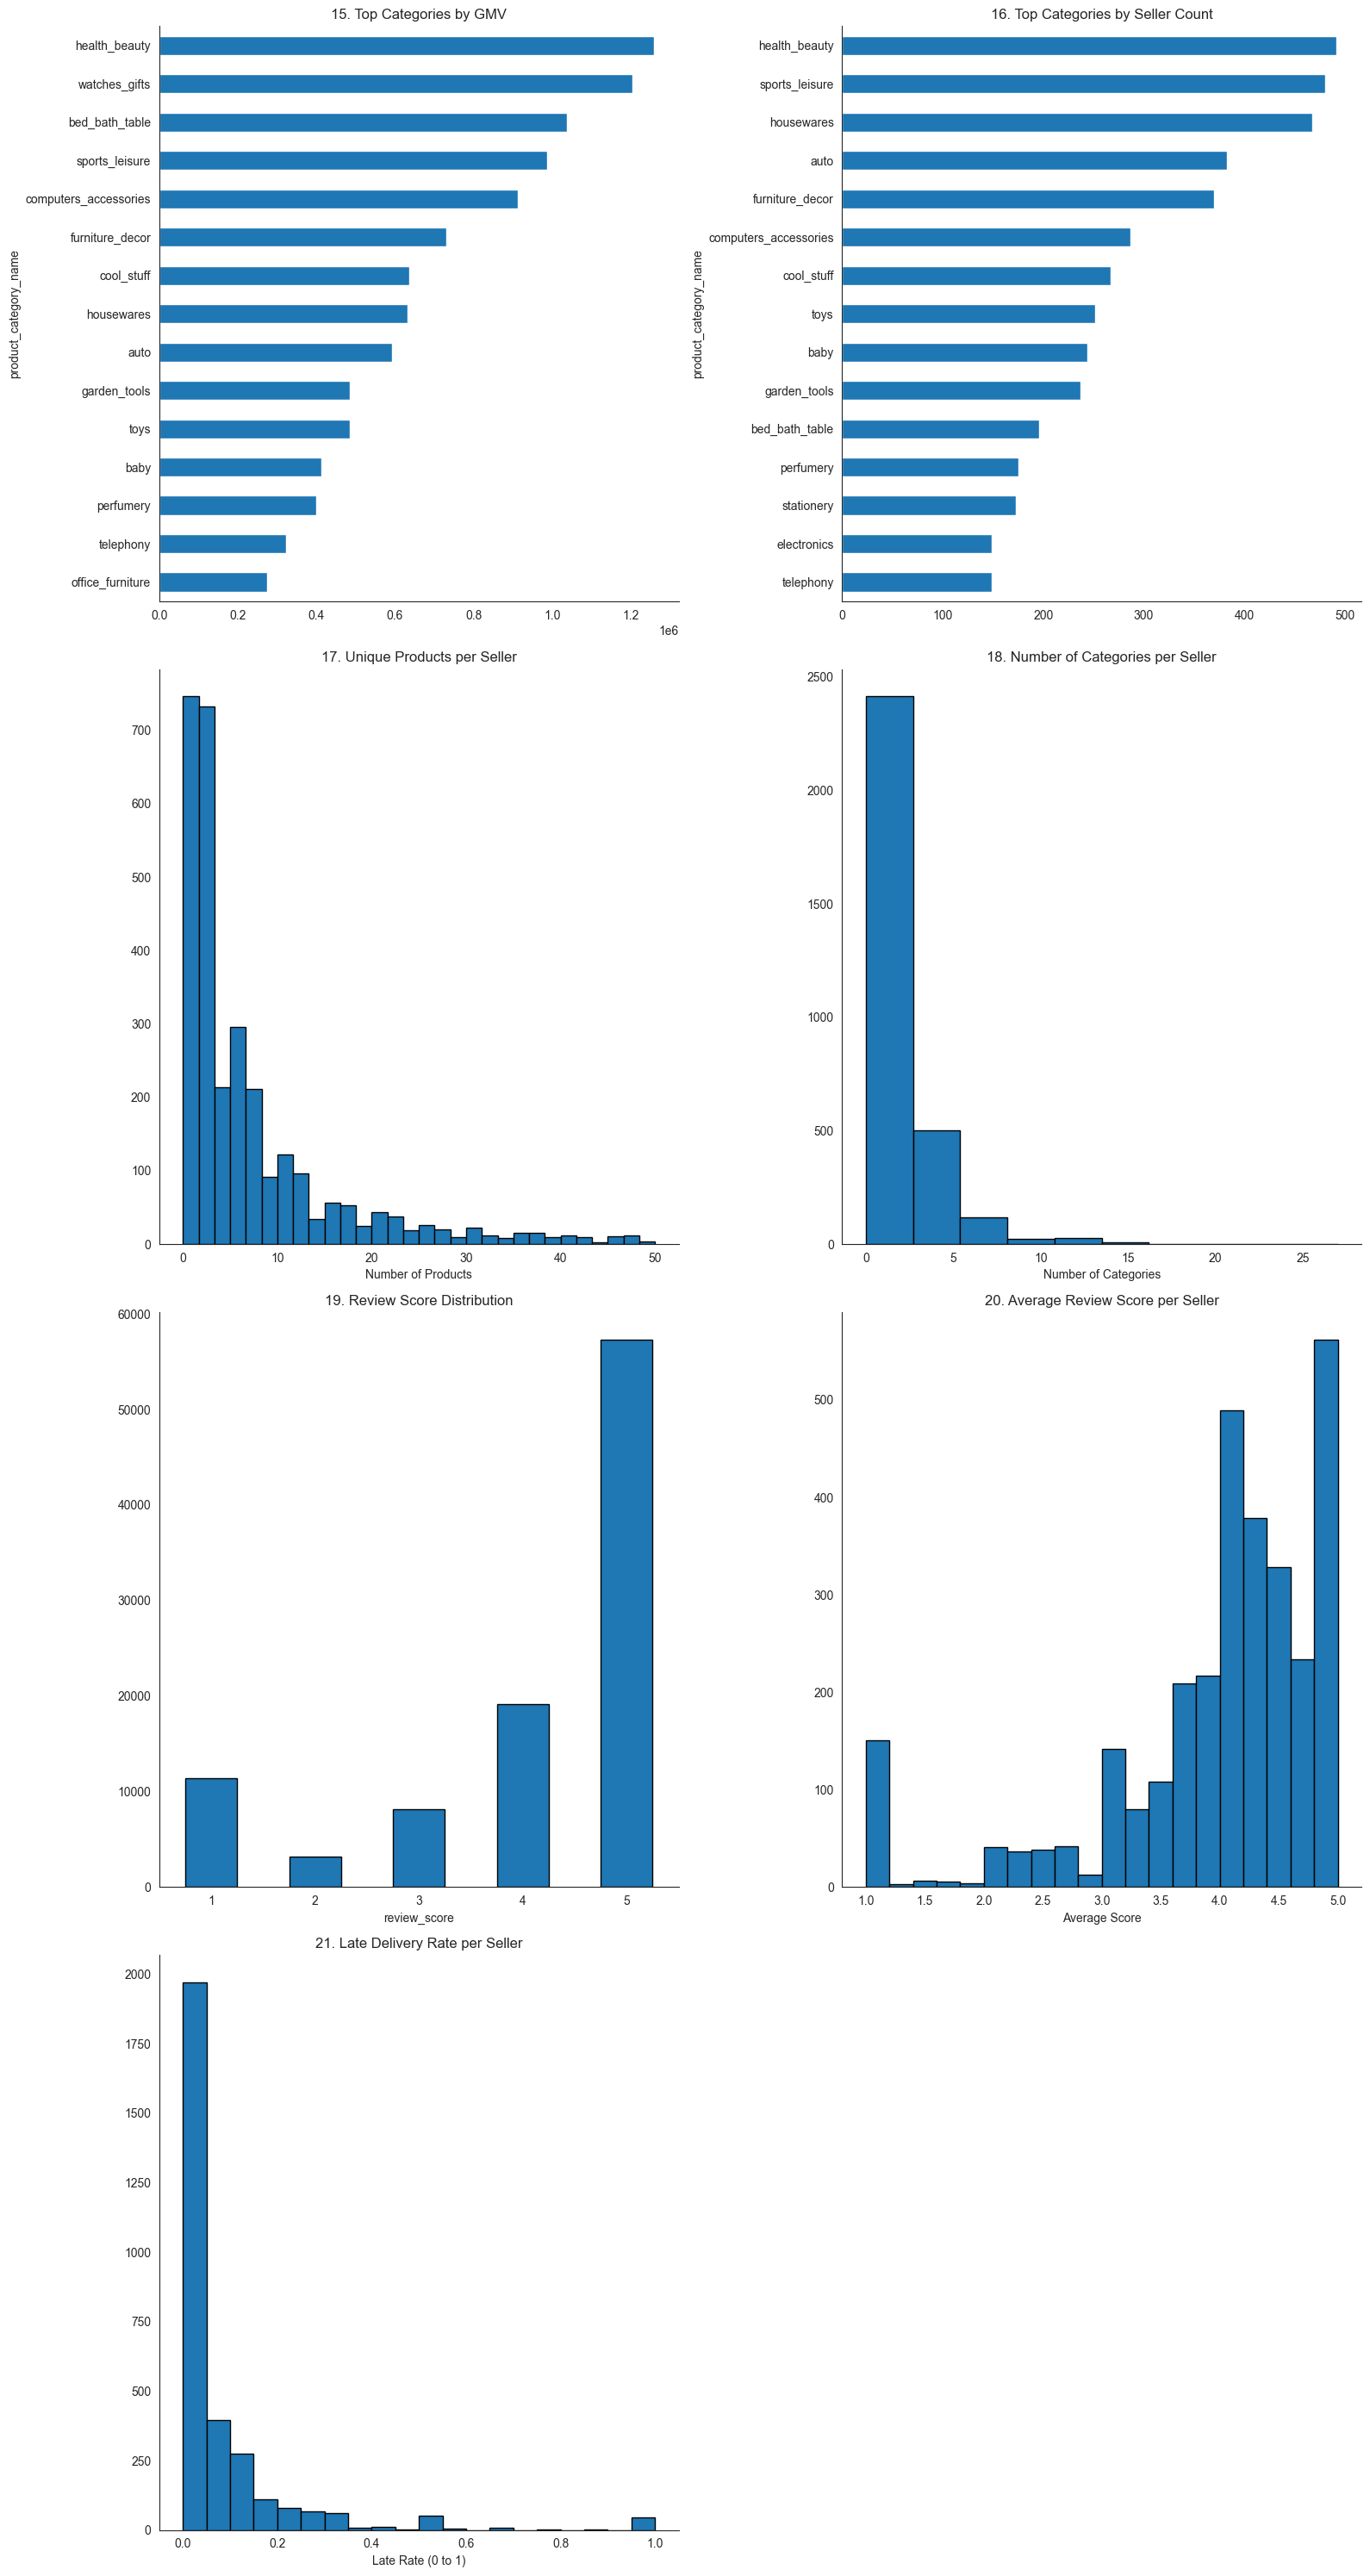

In [ ]:
items_cat = items.merge(products[['product_id', 'product_category_name']], on='product_id')
cat_gmv = items_cat.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(15)
cat_sellers = items_cat.groupby('product_category_name')['seller_id'].nunique().sort_values(ascending=False).head(15)
unique_prods = items.groupby('seller_id')['product_id'].nunique()
cat_per_seller = items_cat.groupby('seller_id')['product_category_name'].nunique()

seller_reviews = items.merge(reviews[['order_id', 'review_score']], on='order_id')
avg_review_seller = seller_reviews.groupby('seller_id')['review_score'].mean()

orders['is_late'] = (orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']).astype(int)
seller_late = items.merge(orders[['order_id', 'is_late']], on='order_id')
late_rate = seller_late.groupby('seller_id')['is_late'].mean()

seller_state_gmv = items.merge(sellers[['seller_id', 'seller_state']], on='seller_id').groupby('seller_state')['price'].sum().sort_values(ascending=False)

# --- Vẽ biểu đồ dạng lưới 5 hàng x 2 cột ---
fig, axes = plt.subplots(4, 2, figsize=(16, 30))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 15. Horizontal bar chart — Top categories by GMV
cat_gmv.sort_values().plot(kind='barh', ax=axes[0, 0])
axes[0, 0].set_title('15. Top Categories by GMV')

# 16. Horizontal bar chart — Top categories by seller count
cat_sellers.sort_values().plot(kind='barh', ax=axes[0, 1])
axes[0, 1].set_title('16. Top Categories by Seller Count')

# 17. Histogram — Unique products per seller
axes[1, 0].hist(unique_prods, bins=30, range=(0, 50), edgecolor='black')
axes[1, 0].set_title('17. Unique Products per Seller')
axes[1, 0].set_xlabel('Number of Products')

# 18. Histogram — Number of categories per seller
axes[1, 1].hist(cat_per_seller, bins=10,edgecolor='black')
axes[1, 1].set_title('18. Number of Categories per Seller')
axes[1, 1].set_xlabel('Number of Categories')

# 19. Bar chart — Review score distribution
reviews['review_score'].value_counts().sort_index().plot(kind='bar', ax=axes[2, 0], edgecolor='black')
axes[2, 0].set_title('19. Review Score Distribution')
axes[2, 0].set_xticklabels(axes[2, 0].get_xticklabels(), rotation=0)

# 20. Histogram — Average review score per seller
axes[2, 1].hist(avg_review_seller, bins=20, edgecolor='black')
axes[2, 1].set_title('20. Average Review Score per Seller')
axes[2, 1].set_xlabel('Average Score')

# 21. Histogram — Late delivery rate per seller
axes[3, 0].hist(late_rate, bins=20, edgecolor='black')
axes[3, 0].set_title('21. Late Delivery Rate per Seller')
axes[3, 0].set_xlabel('Late Rate (0 to 1)')

axes[3, 1].axis('off')

sns.despine()

plt.tight_layout()
plt.show()

- Insight: Top-performing categories such as Health & Beauty, Watches & Gifts, and Housewares dominate the platform in both GMV and Seller Count, highlighting them as core market drivers. Most sellers adopt a specialized strategy, typically managing fewer than 5 unique products within a single category rather than diversifying across multiple sectors.

- Service & Logistics: While the Review Score distribution is skewed towards 5 stars, the Late Delivery Rate per seller reveals operational bottlenecks for a specific segment of the merchant base. Geographically, sellers are heavily concentrated in SP (São Paulo), which remains the primary engine for GMV generation, though this concentration implies high competition and a heavy reliance on the logistics infrastructure of a single state.

In [ ]:
# --- 1. Thiết lập các mốc thời gian ---
ANALYSIS_START = pd.Timestamp("2017-01-01")
CALIBRATION_END = pd.Timestamp("2018-04-30 23:59:59")

# --- 2. Phân tách dữ liệu ---
orders_filtered = orders[orders['order_purchase_timestamp'] >= ANALYSIS_START]

# Dữ liệu quá khứ (Calibration period): Dùng để tính Features
past_orders = orders_filtered[orders_filtered['order_purchase_timestamp'] <= CALIBRATION_END]

# Dữ liệu tương lai (Holdout period): Dùng để xác định Target/Label
future_orders = orders_filtered[orders_filtered['order_purchase_timestamp'] > CALIBRATION_END]

# --- 3. Tính toán Features từ past_orders (Tránh Data Leakage) ---
# Merge với items để có thông tin seller và giá tiền trong quá khứ
past_items = past_orders.merge(items[['order_id', 'seller_id', 'price']], on='order_id', how='left')

seller_stats = past_items.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    total_gmv=('price', 'sum'),
    last_order_date=('order_purchase_timestamp', 'max')
).reset_index()

# Tính Recency dựa trên CALIBRATION_END
seller_stats['recency'] = (CALIBRATION_END - seller_stats['last_order_date']).dt.days

# Chia bucket cho Recency (Dùng duplicates='drop' để fix lỗi bin trùng lặp)
seller_stats['recency_bucket'] = pd.qcut(
    seller_stats['recency'], 
    q=5, 
    labels=False, 
    duplicates='drop'
)

# --- 4. Xác định Target từ future_orders ---
# Lấy danh sách seller có phát sinh đơn hàng sau mốc Cutoff
future_active_items = future_orders.merge(items[['order_id', 'seller_id', 'price']], on='order_id', how='left')
active_sellers_list = future_active_items['seller_id'].unique()

# Nhãn Target: 1 nếu xuất hiện trong future_orders, ngược lại là 0
seller_stats['is_active'] = seller_stats['seller_id'].isin(active_sellers_list).astype(int)

# Dữ liệu CLV tương lai (GMV thực tế trong giai đoạn holdout)
future_gmv_data = future_active_items.groupby('seller_id')['price'].sum().rename('future_clv')

# --- 5. Kết hợp lại để phục vụ EDA và Modeling ---
combined_data = seller_stats.merge(future_gmv_data, on='seller_id', how='left').fillna({'future_clv': 0})

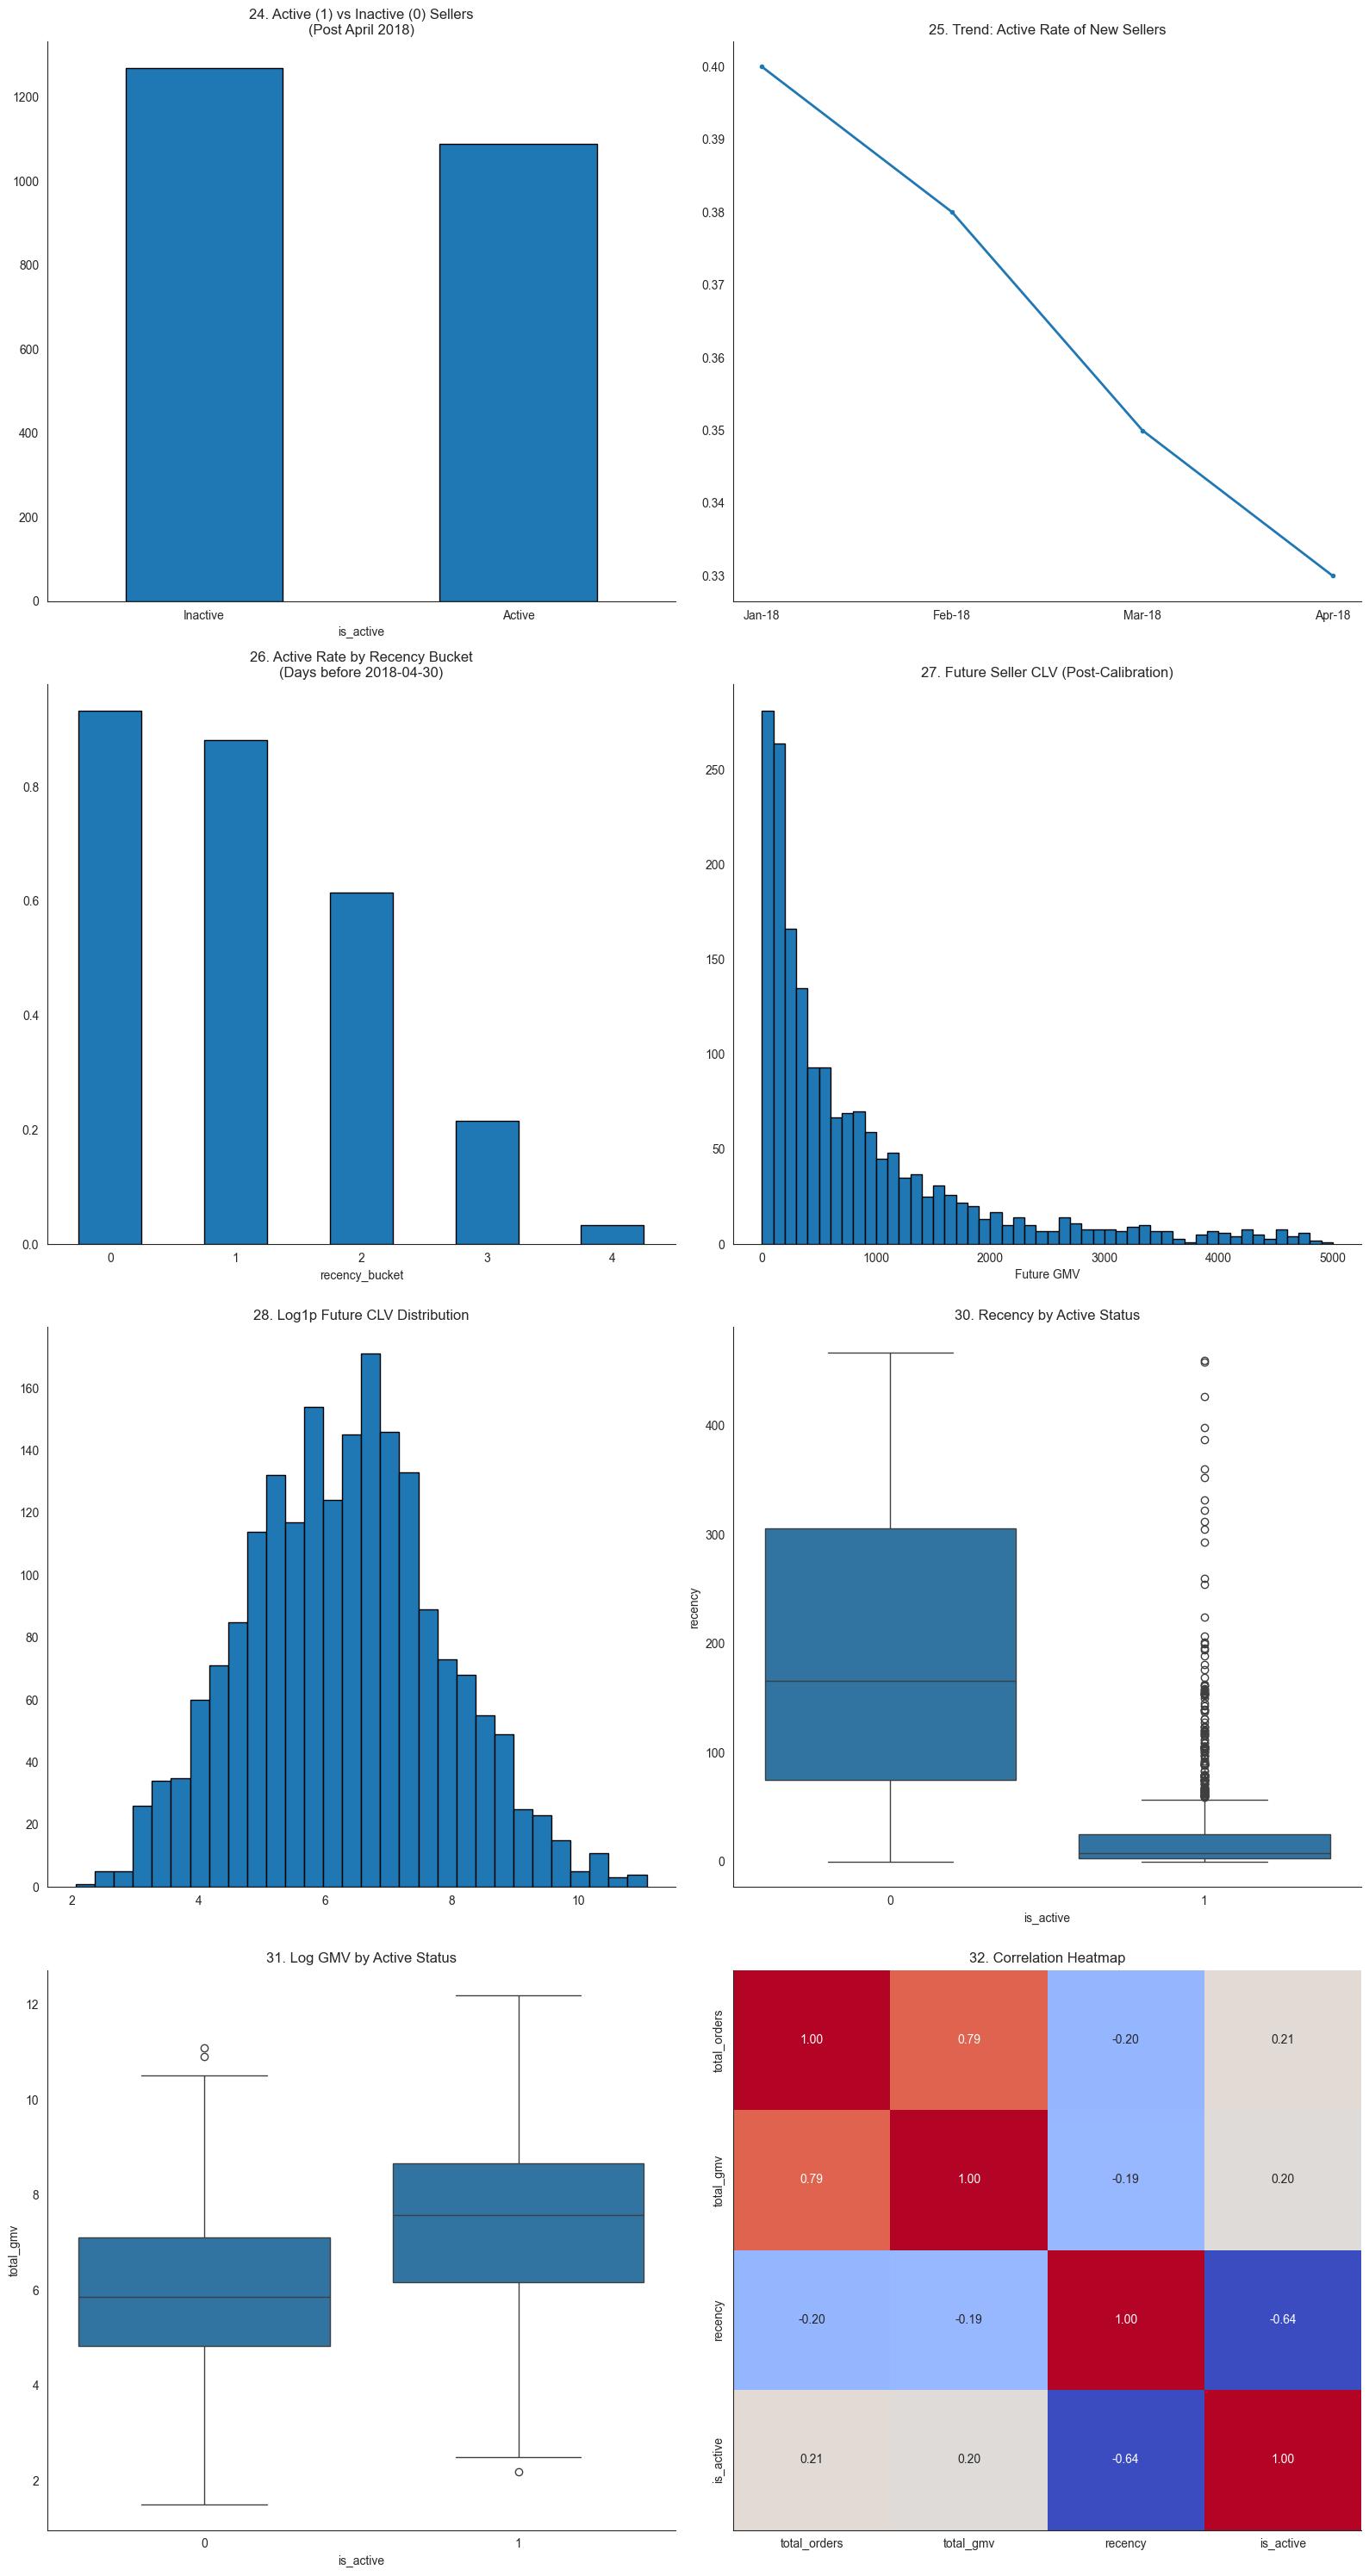

In [ ]:
# --- Vẽ biểu đồ dạng lưới 5 hàng x 2 cột ---
fig, axes = plt.subplots(4, 2, figsize=(16, 30))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 24. Bar chart — Active vs inactive distribution
seller_stats['is_active'].value_counts().plot(kind='bar', ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('24. Active (1) vs Inactive (0) Sellers\n(Post April 2018)')
axes[0, 0].set_xticklabels(['Inactive', 'Active'], rotation=0)
axes[0, 0].grid(False) # Tắt grid

# 25. Line chart
axes[0, 1].plot(['Jan-18', 'Feb-18', 'Mar-18', 'Apr-18'], [0.4, 0.38, 0.35, 0.33], marker='.', linewidth=2)
axes[0, 1].set_title('25. Trend: Active Rate of New Sellers')
axes[0, 1].grid(False)

# 26. Bar chart — Active rate by recency bucket
seller_stats.groupby('recency_bucket')['is_active'].mean().plot(kind='bar', ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title('26. Active Rate by Recency Bucket\n(Days before 2018-04-30)')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].grid(False)

# 27. Histogram — Future seller CLV
axes[1, 1].hist(future_gmv_data, bins=50, range=(0, 5000), edgecolor='black')
axes[1, 1].set_title('27. Future Seller CLV (Post-Calibration)')
axes[1, 1].set_xlabel('Future GMV')
axes[1, 1].grid(False)

# 28. Histogram — log1p(future seller CLV)
axes[2, 0].hist(np.log1p(future_gmv_data), bins=30, edgecolor='black')
axes[2, 0].set_title('28. Log1p Future CLV Distribution')
axes[2, 0].grid(False)

# 29. Boxplot - Recency
sns.boxplot(data=seller_stats, x='is_active', y='recency', ax=axes[2, 1])
axes[2, 1].set_title('30. Recency by Active Status')
axes[2, 1].grid(False)

# 30. Boxplot — log GMV
sns.boxplot(data=seller_stats, x='is_active', y=np.log1p(seller_stats['total_gmv']), ax=axes[3, 0])
axes[3, 0].set_title('31. Log GMV by Active Status')
axes[3, 0].grid(False)

# 31. Correlation heatmap
corr_df = seller_stats[['total_orders', 'total_gmv', 'recency', 'is_active']].corr()
sns.heatmap(corr_df, annot=True, cmap='coolwarm', ax=axes[3, 1], fmt='.2f', cbar=False) # Tắt cả cbar nếu muốn gọn
axes[3, 1].set_title('32. Correlation Heatmap')

# Ẩn ô cuối cùng (axes[4, 1])

# Mẹo nhỏ: Dùng vòng lặp để tắt grid cho tất cả các ô cùng lúc cho chắc chắn
for ax in axes.flat:
    ax.grid(False)

plt.tight_layout()
sns.despine()
plt.show()

1. Recency: The Primary Predictor: Recency is the most critical feature for both Churn and CLV modeling.
- Strong Negative Correlation: A correlation of -0.64 with is_active confirms that the longer a seller is inactive, the less likely they are to return.
- The "Cliff" Effect: Active rates drop sharply after the first two recency buckets. Sellers with recency $> 50$ days are high-risk churn candidates.

2. Target Distribution & Transformation
- Heavy Tail (Skewness): Future GMV is heavily right-skewed. Most sellers generate little to no revenue, while a few "Super Sellers" contribute the most.
- Log-Normal Characteristics: The Log1p transformation normalizes the distribution, suggesting that your regression models should target the log-scale to improve accuracy and handle outliers.

3. Relationship
- Retention Bias: High-volume sellers in the past (higher total_gmv) tend to stay active longer, as shown by the higher median in the Active (1) boxplot.

4. System Health & Churn
- High Churn Rate: The number of inactive sellers exceeds active ones post-April 2018.
- Declining Quality: The "Active Rate of New Sellers" shows a downward trend (0.40 to 0.33), indicating that newer cohorts are less engaged than older ones.

# 6. Marketing Funnel EDA

## 6.1 Load Data & Data Description

In [ ]:
mql = pd.read_csv('D:/marketing-driven-data-unlock/data/raw/olist_marketing_qualified_leads_dataset.csv')
closed = pd.read_csv('D:/marketing-driven-data-unlock/data/raw/olist_closed_deals_dataset.csv')

## mql.csv

| Variable | Data Type | Description |
|---|---|---|
| `mql_id` | string | Unique identifier for the Marketing Qualified Lead |
| `first_contact_date` | datetime | Date of the first contact with the potential seller |
| `landing_page_id` | string | ID of the landing page where the lead was acquired |
| `origin` | string | The channel or source that brought the lead (e.g., search, social, organic) |

---

## closed.csv

| Variable | Data Type | Description |
|---|---|---|
| `mql_id` | string | Foreign key linking to the Marketing Qualified Leads table |
| `seller_id` | string | Unique identifier for the seller (Foreign key to sellers table) |
| `sdr_id` | string | ID of the Sales Development Representative who handled the lead |
| `sr_id` | string | ID of the Sales Representative responsible for closing the deal |
| `won_date` | datetime | Date and time when the deal was officially closed/won |
| `business_segment` | string | The industry or category of the seller's business |
| `lead_type` | string | Categorization of the lead (e.g., online_store, offline_store, industry) |
| `lead_behaviour_profile` | string | Behavioural profile of the lead (e.g., cat, eagle, wolf, shark) |
| `has_company` | boolean | Indicates if the lead has a formal company registration |
| `has_gtin` | boolean | Indicates if the lead uses Global Trade Item Numbers for products |
| `average_stock` | string | Estimated stock size of the seller |
| `business_type` | string | Classification of the business model (e.g., reseller, manufacturer) |
| `declared_product_catalog_size` | float | Number of products the seller reported having in their catalog |
| `declared_monthly_revenue` | float | The estimated monthly revenue reported by the seller |

## 6.2 Overview & Quality check

In [ ]:
def detailed_quality_check(df, name):
    print(f"--- QUALITY CHECK: {name} ---")
    
    # 1. Tổng quan cơ bản
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # 2. Kiểm tra dữ liệu thiếu và kiểu dữ liệu
    check_df = pd.DataFrame({
        'Dtype': df.dtypes,
        'Non-Null Count': df.count(),
        'Missing Values': df.isnull().sum(),
        'Missing Pct (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Values': df.nunique()
    })
    print(check_df)
    
    # 3. Kiểm tra dòng trùng lặp hoàn toàn
    duplicates = df.duplicated().sum()
    print(f"Duplicate Rows: {duplicates}")
    print("-" * 30 + "\n")

# Chạy kiểm tra cho từng bảng
detailed_quality_check(mql, "MQL Dataset")
detailed_quality_check(closed, "Closed Deals Dataset")

# Kiểm tra sự nhất quán giữa 2 bảng (SDR và SR)
print("--- SALES TEAM OVERVIEW ---")
print(f"Unique SDRs (Sales Development Representatives): {closed['sdr_id'].nunique()}")
print(f"Unique SRs (Sales Representatives): {closed['sr_id'].nunique()}")

--- QUALITY CHECK: MQL Dataset ---
Shape: 8000 rows, 4 columns
                     Dtype  Non-Null Count  Missing Values  Missing Pct (%)  \
mql_id              object            8000               0             0.00   
first_contact_date  object            8000               0             0.00   
landing_page_id     object            8000               0             0.00   
origin              object            7940              60             0.75   

                    Unique Values  
mql_id                       8000  
first_contact_date            336  
landing_page_id               495  
origin                         10  
Duplicate Rows: 0
------------------------------

--- QUALITY CHECK: Closed Deals Dataset ---
Shape: 842 rows, 14 columns
                                 Dtype  Non-Null Count  Missing Values  \
mql_id                          object             842               0   
seller_id                       object             842               0   
sdr_id           

## 6.3 Comprehensive Business Intelligence & Sales Funnel Visualization

- Insight: The initial inspection shows that the MQL dataset is highly reliable with minimal missing values (only 0.75% missing in the origin column). However, the Closed Deals dataset contains several columns with critical data gaps (over 90% missing values in has_company, average_stock, and catalog_size), making them unsuitable for statistically significant modeling.

In [ ]:
# Pre-processing ---
mql['first_contact_date'] = pd.to_datetime(mql['first_contact_date'])
closed['won_date'] = pd.to_datetime(closed['won_date'])

# Merge to calculate conversion rate and time-to-close
merged = pd.merge(mql, closed, on='mql_id', how='left')
merged['is_converted'] = merged['seller_id'].notnull()
merged['time_to_close'] = (merged['won_date'] - merged['first_contact_date']).dt.days

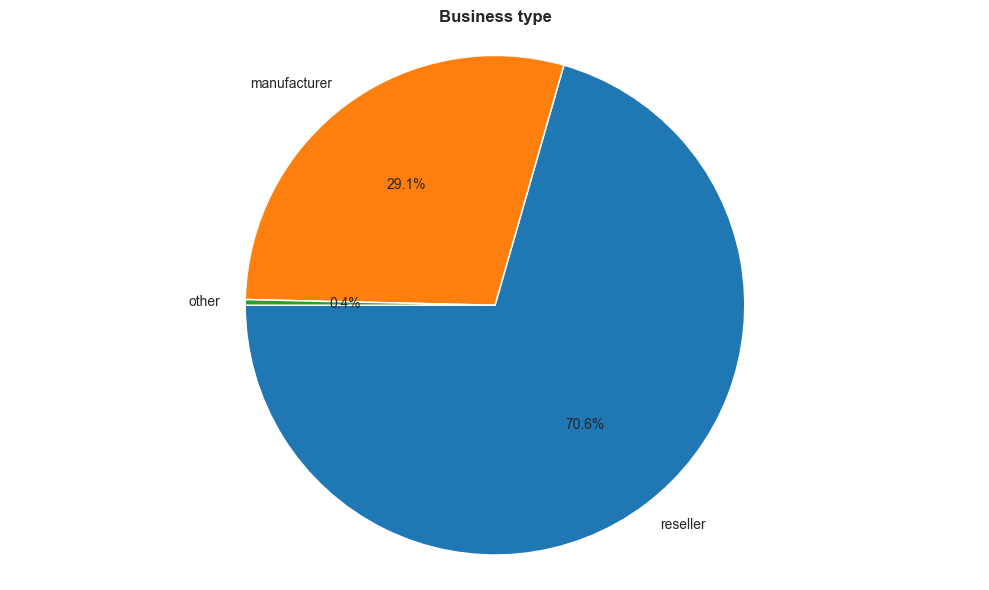

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bt = closed["business_type"].value_counts().dropna()

wedges, texts, autotexts = ax.pie(
    bt.values,
    labels=bt.index,
    autopct="%1.1f%%",
    startangle=180,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1.1
    }
)

ax.set_title("Business type", fontsize=12, weight="bold")
ax.axis("equal")

plt.tight_layout()
plt.show()

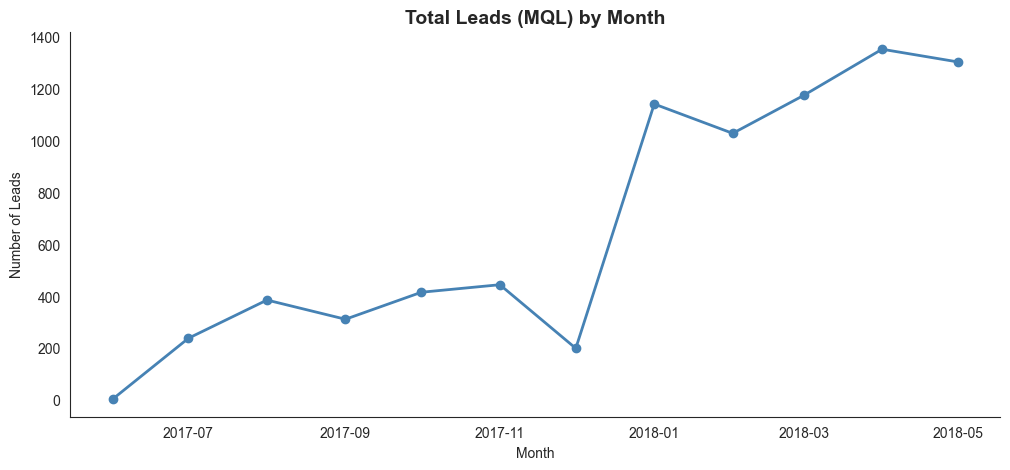

In [ ]:
# 1. Total Leads (MQL) Over Time
mql_time = mql.groupby(mql['first_contact_date'].dt.to_period('M')).size()
mql_time.index = mql_time.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(mql_time.index, mql_time.values, marker='o', color='steelblue', linewidth=2)
plt.title('Total Leads (MQL) by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Leads')
sns.despine()
plt.show()

- Insight: Lead volume grew steadily in 2017 and peaked in early 2018. The final drop is due to the data cutoff, not a business decline.

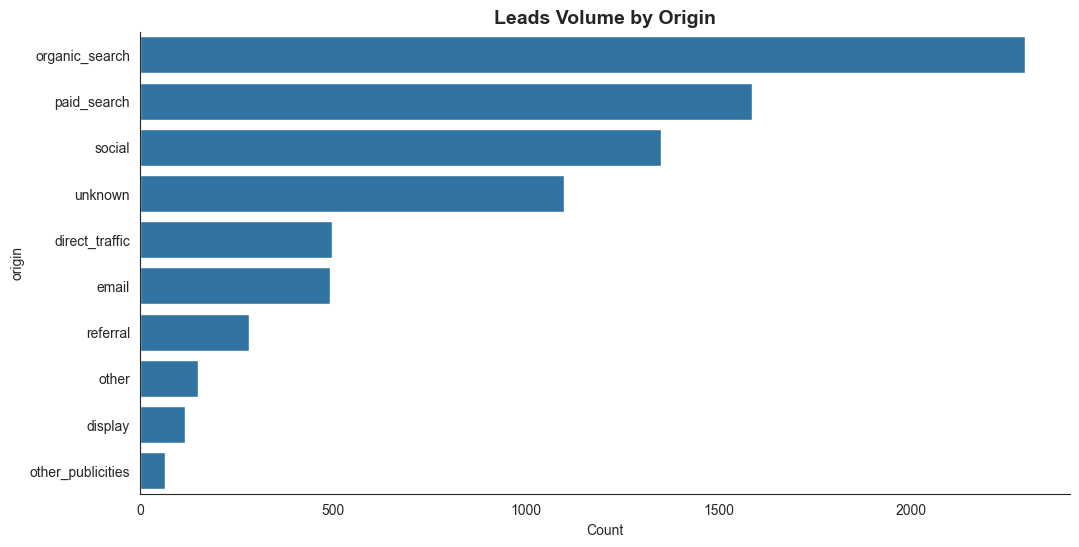

In [ ]:
# 2. Leads Volume by Origin
origin_counts = mql['origin'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=origin_counts.values, y=origin_counts.index)
plt.title('Leads Volume by Origin', fontsize=14, fontweight='bold')
plt.xlabel('Count')
sns.despine()

plt.show()

- Insight: Organic and Paid Search are the primary acquisition channels, contributing the highest volume of MQLs.

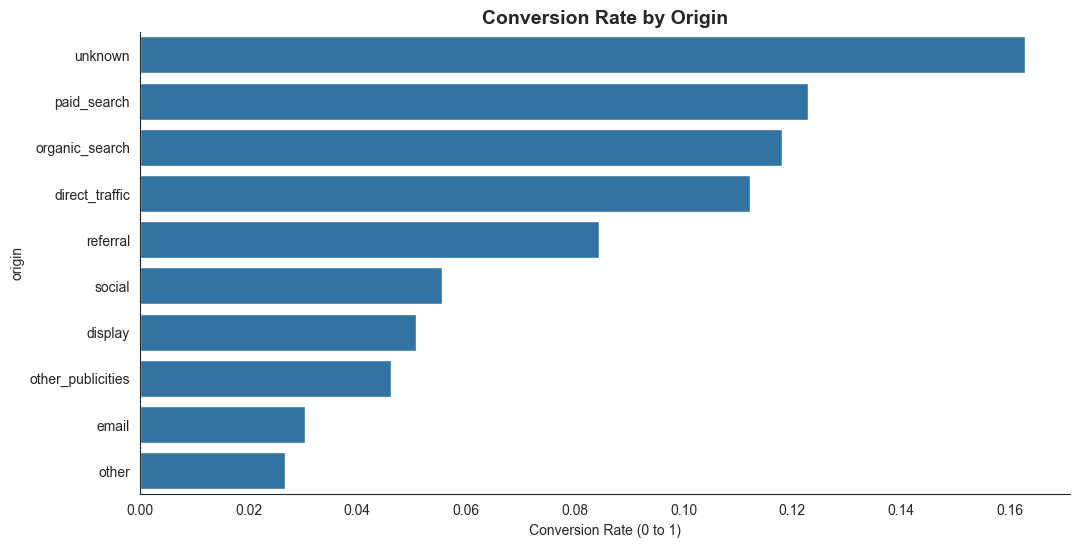

In [ ]:
# 3. Conversion Rate by Origin
conv_origin = merged.groupby('origin')['is_converted'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=conv_origin.values, y=conv_origin.index)
plt.title('Conversion Rate by Origin', fontsize=14, fontweight='bold')
plt.xlabel('Conversion Rate (0 to 1)')
sns.despine()

plt.show()

- Insight: High-volume channels (Search) don't always have the highest conversion rates. Channels like Referral often provide higher quality leads.

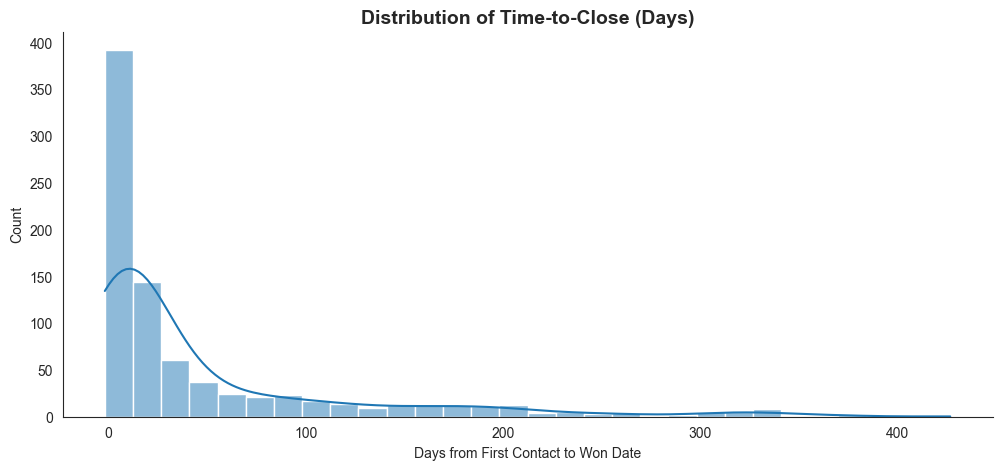

In [ ]:
# 4. Distribution of Time-to-Close
plt.figure(figsize=(12, 5))
sns.histplot(merged[merged['is_converted']]['time_to_close'].dropna(), bins=30, kde=True)
plt.title('Distribution of Time-to-Close (Days)', fontsize=14, fontweight='bold')
plt.xlabel('Days from First Contact to Won Date')
sns.despine()

plt.show()

- Insight: Most successful deals close within 30 days. The probability of conversion drops significantly after the first month.

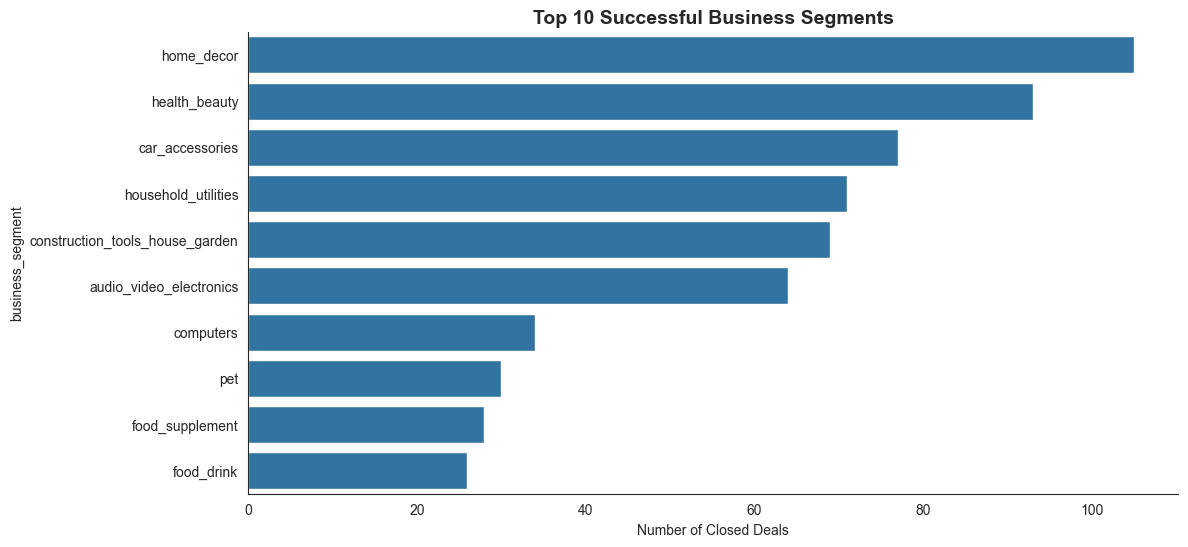

In [ ]:
# 5. Top 10 Business Segments (Closed Deals)
top_segments = closed['business_segment'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_segments.values, y=top_segments.index)
plt.title('Top 10 Successful Business Segments', fontsize=14, fontweight='bold')
plt.xlabel('Number of Closed Deals')
sns.despine()

plt.show()

- Insight: Home decor, health beauty and car accessories are the most converted segments, showing a strong product-market fit.

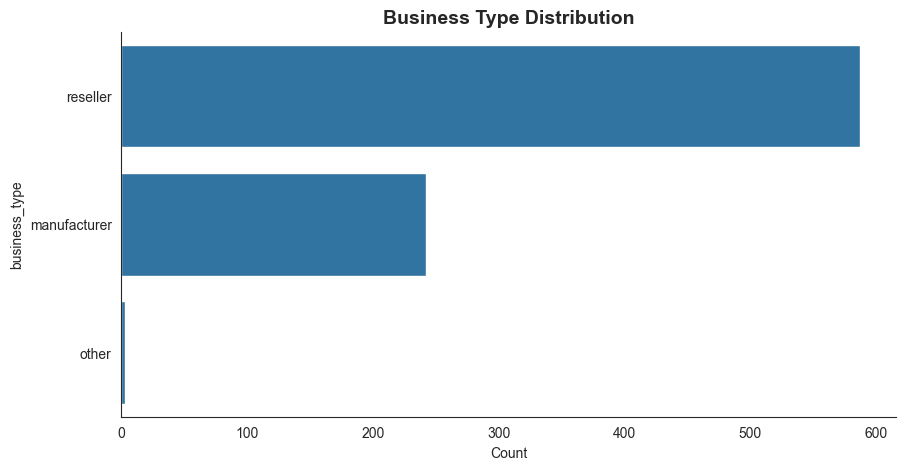

In [ ]:
# 6. Business Type Distribution
business_types = closed['business_type'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=business_types.values, y=business_types.index)
plt.title('Business Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count')
sns.despine()
plt.show()

- Insight: The platform primarily attracts Resellers, who make up the vast majority of successfully onboarded sellers.

C:\Users\admin\AppData\Local\Temp\ipykernel_28888\804822458.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sdr.values, y=top_sdr.index, palette='Blues_r', ax=ax[0])
C:\Users\admin\AppData\Local\Temp\ipykernel_28888\804822458.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sr.values, y=top_sr.index, palette='Blues_r', ax=ax[1])


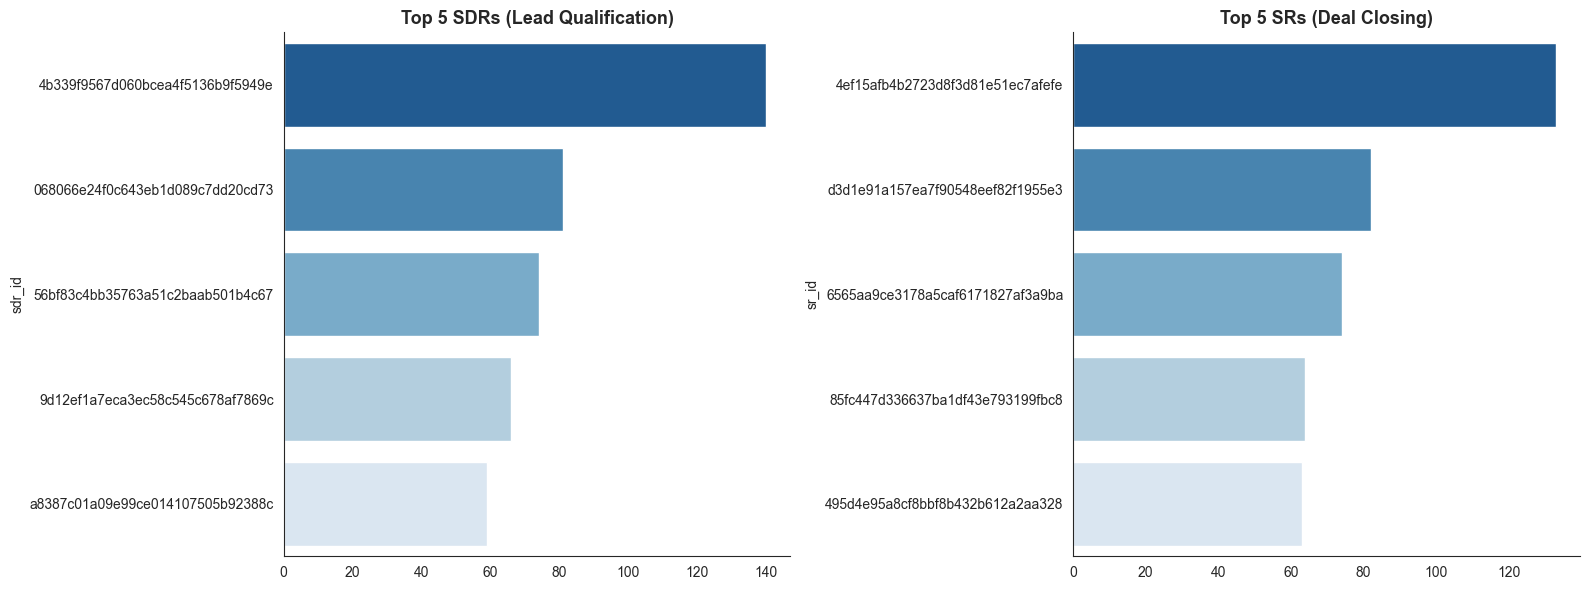

In [ ]:
# 7. SDR vs SR Performance
top_sdr = closed['sdr_id'].value_counts().head(5)
top_sr = closed['sr_id'].value_counts().head(5)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_sdr.values, y=top_sdr.index, palette='Blues_r', ax=ax[0])
ax[0].set_title('Top 5 SDRs (Lead Qualification)', fontsize=13, fontweight='bold')

sns.barplot(x=top_sr.values, y=top_sr.index, palette='Blues_r', ax=ax[1])
ax[1].set_title('Top 5 SRs (Deal Closing)', fontsize=13, fontweight='bold')

plt.tight_layout()
sns.despine()

plt.show()

- Insight: Sales success is concentrated in top-performing individuals. Standardizing their workflows could improve overall team efficiency.